In [1]:
# Connect Google Drive so our files are saved permanently
from google.colab import drive
drive.mount('/content/drive')

import os

# Your Drive folder (the name must match exactly, including capitals and spaces)
PROJECT_DIR = '/content/drive/MyDrive/Computer Vision CW'
assert os.path.isdir(PROJECT_DIR), f'Folder not found: {PROJECT_DIR}'

# Subfolders inside your Drive folder
FIG_DIR       = os.path.join(PROJECT_DIR, 'figures')    # charts for the report
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'processed')  # cleaned images (Step 2)
MODEL_DIR     = os.path.join(PROJECT_DIR, 'models')     # trained models (Steps 4-5)
RESULTS_DIR   = os.path.join(PROJECT_DIR, 'results')    # scores and results (Step 6)

# Colab's own fast disk, used for raw images while we work
DATA_DIR = '/content/data'

for d in [FIG_DIR, PROCESSED_DIR, MODEL_DIR, RESULTS_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

!nvidia-smi -L    # confirms the GPU is on

Mounted at /content/drive
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# RESUME CELL: run Cell 1, then this, in any new session (replaces Cells 2-22)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2

IMG_SIZE, VERSIONS = 224, ['v0', 'v1', 'v2']
STAGE_NAMES = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}
STAGES = list(STAGE_NAMES.values())

def save_fig(name):
    """Save the current chart to Drive in high quality for the report."""
    plt.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=200, bbox_inches='tight')

df = pd.read_csv(os.path.join(PROCESSED_DIR, 'metadata.csv'))
arrays = {}
for v in VERSIONS:
    data = np.load(os.path.join(PROCESSED_DIR, f'{v}_{IMG_SIZE}.npz'))
    assert (data['id_code'] == df['id_code'].values).all(), 'Image order does not match metadata!'
    arrays[v] = data['images']
print('Loaded. Images per split:')
print(df['split'].value_counts())

Loaded. Images per split:
split
train      2436
test        523
val         522
removed     181
Name: count, dtype: int64


In [ ]:
#cell 2
import shutil

ZIP_NAME  = 'aptos2019-blindness-detection.zip'
DRIVE_ZIP = os.path.join(PROJECT_DIR, 'raw', ZIP_NAME)  # backup copy in your Drive
LOCAL_ZIP = os.path.join(DATA_DIR, ZIP_NAME)            # working copy on Colab's disk
os.makedirs(os.path.dirname(DRIVE_ZIP), exist_ok=True)

if os.path.exists(DRIVE_ZIP):
    # Already downloaded before: copy from Drive, no Kaggle needed
    print('Found zip in Drive, copying to Colab disk...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
else:
    # First time only: download from Kaggle, then save a backup to Drive
    print('First run, downloading from Kaggle...')
    from google.colab import userdata
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')  # read the hidden token
    !pip install -q -U kaggle
    !kaggle competitions download -c aptos2019-blindness-detection -p {DATA_DIR}
    print('Saving a backup copy to Drive (takes several minutes)...')
    shutil.copy(LOCAL_ZIP, DRIVE_ZIP)

print('Done:', round(os.path.getsize(LOCAL_ZIP) / 1e9, 2), 'GB')

Found zip in Drive, copying to Colab disk...
Done: 10.22 GB


In [ ]:
#cell 3
# Take out only the training images and their labels
!unzip -q -o {LOCAL_ZIP} "train_images/*" "train.csv" -d {DATA_DIR}/aptos
!rm {LOCAL_ZIP}                             # delete the Colab copy (the Drive backup stays safe)
!ls {DATA_DIR}/aptos/train_images | wc -l   # count the images

3662


In [ ]:
#cell 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = os.path.join(DATA_DIR, 'aptos', 'train_images')

# train.csv has 2 columns: id_code (image name) and diagnosis (stage 0-4)
df = pd.read_csv(os.path.join(DATA_DIR, 'aptos', 'train.csv'))

STAGE_NAMES = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}
df['stage']  = df['diagnosis'].map(STAGE_NAMES)             # stage number -> name
df['path']   = IMG_DIR + '/' + df['id_code'] + '.png'       # full path to each image
df['has_dr'] = (df['diagnosis'] > 0).astype(int)            # 0 = healthy, 1 = has DR (any stage)

def save_fig(name):
    """Save the current chart to Drive in high quality for the report."""
    plt.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=200, bbox_inches='tight')

print(df.shape)
df.head()

(3662, 5)


,id_code,diagnosis,stage,path,has_dr
0,000c1434d8d7,2,Moderate,/content/data/aptos/train_images/000c1434d8d7.png,1
1,001639a390f0,4,Proliferative,/content/data/aptos/train_images/001639a390f0.png,1
2,0024cdab0c1e,1,Mild,/content/data/aptos/train_images/0024cdab0c1e.png,1
3,002c21358ce6,0,No DR,/content/data/aptos/train_images/002c21358ce6.png,0
4,005b95c28852,0,No DR,/content/data/aptos/train_images/005b95c28852.png,0


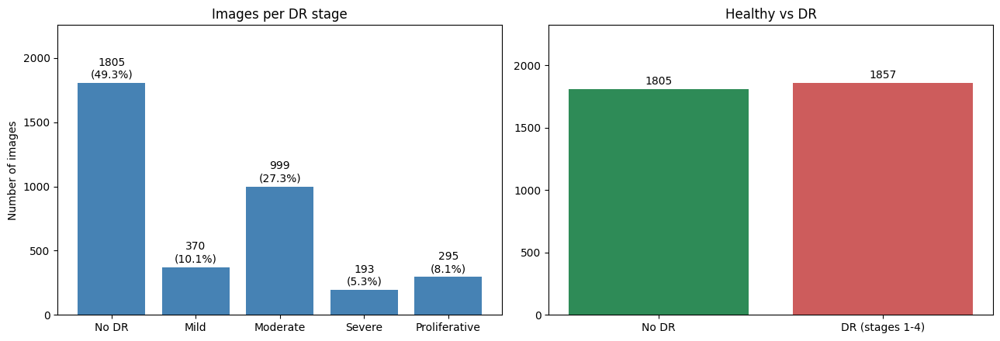

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64
Biggest class is 9.4x bigger than the smallest


In [ ]:
#cell 5
counts = df['diagnosis'].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left chart: images per stage (5 classes)
bars = axes[0].bar([STAGE_NAMES[i] for i in counts.index], counts.values, color='steelblue')
for b, c, p in zip(bars, counts.values, pct.values):
    axes[0].text(b.get_x() + b.get_width() / 2, c + 20, f'{c}\n({p}%)', ha='center', va='bottom')
axes[0].set_title('Images per DR stage')
axes[0].set_ylabel('Number of images')
axes[0].set_ylim(0, counts.max() * 1.25)

# Right chart: healthy vs DR (2 classes)
b_counts = df['has_dr'].value_counts().sort_index()
axes[1].bar(['No DR', 'DR (stages 1-4)'], b_counts.values, color=['seagreen', 'indianred'])
for i, c in enumerate(b_counts.values):
    axes[1].text(i, c + 20, str(c), ha='center', va='bottom')
axes[1].set_title('Healthy vs DR')
axes[1].set_ylim(0, b_counts.max() * 1.25)

plt.tight_layout(); save_fig('01_class_distribution'); plt.show()
print(counts)
print(f'Biggest class is {counts.max() / counts.min():.1f}x bigger than the smallest')

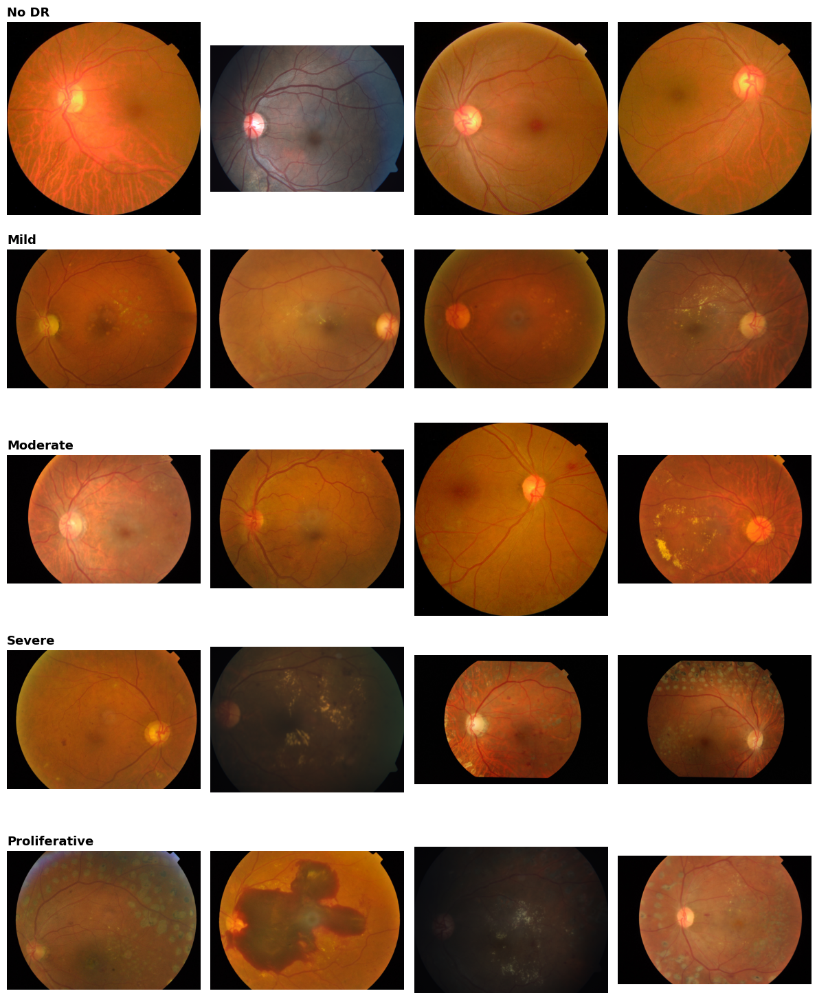

In [ ]:
#cell 6
# Show 4 random images from each stage
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for stage in range(5):
    sample = df[df['diagnosis'] == stage].sample(4, random_state=42)  # random_state = same images every run
    for j, path in enumerate(sample['path']):
        axes[stage, j].imshow(Image.open(path))
        axes[stage, j].axis('off')
    axes[stage, 0].set_title(STAGE_NAMES[stage], loc='left', fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig('02_sample_images'); plt.show()

        width  height
count  3662.0  3662.0
mean   2015.0  1527.0
std     884.0   543.0
min     474.0   358.0
25%    1050.0  1050.0
50%    2144.0  1536.0
75%    2588.0  1958.0
max    4288.0  2848.0

Number of different image sizes: 17


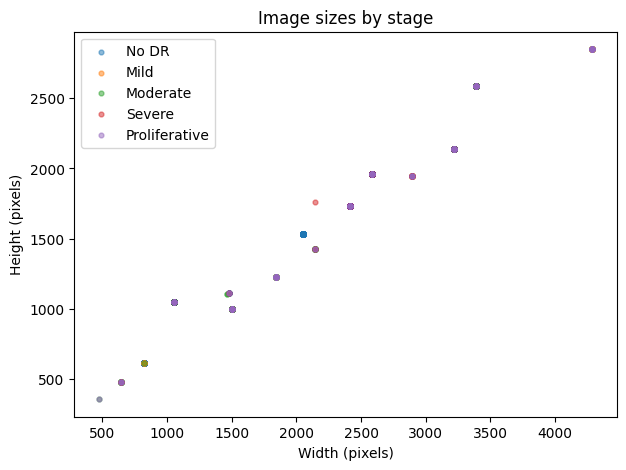

In [ ]:
#cell 7
# Read each image's width and height (fast, because it only reads the file header)
sizes = [Image.open(p).size for p in df['path']]
df['width']  = [w for w, h in sizes]
df['height'] = [h for w, h in sizes]

print(df[['width', 'height']].describe().round(0))
print('\nNumber of different image sizes:', df.groupby(['width', 'height']).ngroups)

plt.figure(figsize=(7, 5))
for stage in range(5):
    s = df[df['diagnosis'] == stage]
    plt.scatter(s['width'], s['height'], s=12, alpha=0.5, label=STAGE_NAMES[stage])
plt.xlabel('Width (pixels)'); plt.ylabel('Height (pixels)')
plt.title('Image sizes by stage')
plt.legend(); save_fig('03_image_sizes'); plt.show()

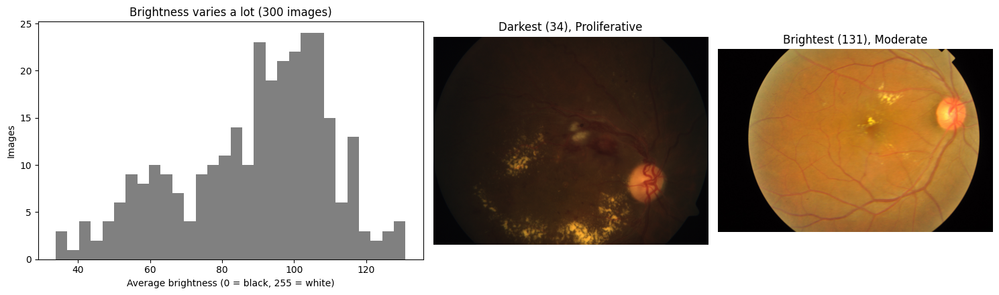

In [ ]:
#cell 8
# Measure the average brightness of 300 random images
sample = df.sample(300, random_state=42)
brightness = []
for p in sample['path']:
    img = Image.open(p).convert('L')         # convert to black-and-white
    img.thumbnail((512, 512))                # make it smaller first (much faster)
    arr = np.asarray(img, dtype=np.float32)
    brightness.append(arr[arr > 10].mean())  # skip the black border, measure only the eye
sample = sample.assign(brightness=brightness)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={'width_ratios': [1.4, 1, 1]})
axes[0].hist(sample['brightness'], bins=30, color='gray')
axes[0].set_xlabel('Average brightness (0 = black, 255 = white)'); axes[0].set_ylabel('Images')
axes[0].set_title('Brightness varies a lot (300 images)')
for ax, row, label in [(axes[1], sample.loc[sample['brightness'].idxmin()], 'Darkest'),
                       (axes[2], sample.loc[sample['brightness'].idxmax()], 'Brightest')]:
    ax.imshow(Image.open(row['path'])); ax.axis('off')
    ax.set_title(f"{label} ({row['brightness']:.0f}), {row['stage']}")
plt.tight_layout(); save_fig('04_brightness'); plt.show()

In [ ]:
#to get sizes for cell 9
# Make sure image sizes exist (creates them if Cell 7 wasn't run in this session)
if 'width' not in df.columns:
    print('Image sizes missing, reading them now...')
    sizes = [Image.open(p).size for p in df['path']]
    df['width']  = [w for w, h in sizes]
    df['height'] = [h for w, h in sizes]

Image sizes missing, reading them now...


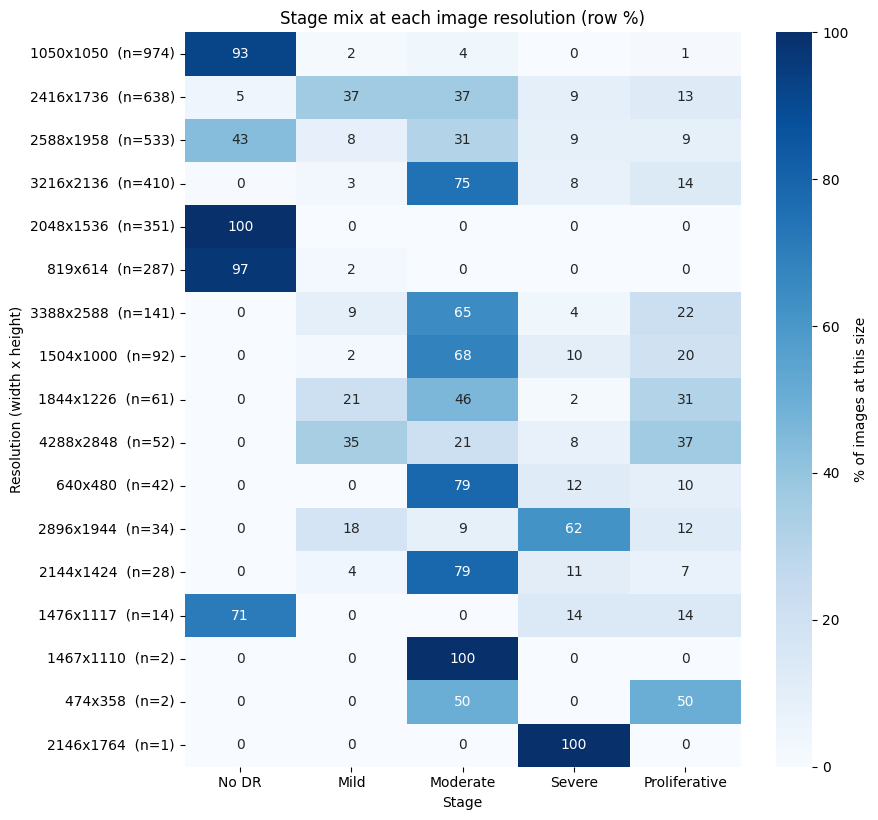

Different resolutions: 17
Always guessing "No DR":       49.3% accuracy
Guessing from image size only: 70.8% accuracy


In [ ]:
#cell 9
import seaborn as sns

STAGES = list(STAGE_NAMES.values())

# Count how many images of each stage exist at each resolution
df['resolution'] = df['width'].astype(str) + 'x' + df['height'].astype(str)
ct = pd.crosstab(df['resolution'], df['stage'])[STAGES]  # rows = sizes, columns = stages
ct['Total'] = ct.sum(axis=1)
ct = ct.sort_values('Total', ascending=False)

# Turn counts into % per row: "at this size, what % of images are each stage?"
row_pct = ct[STAGES].div(ct['Total'], axis=0) * 100

plt.figure(figsize=(9, 0.4 * len(ct) + 1.5))
sns.heatmap(row_pct, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '% of images at this size'},
            yticklabels=[f'{r}  (n={n})' for r, n in zip(ct.index, ct['Total'])])
plt.title('Stage mix at each image resolution (row %)')
plt.xlabel('Stage'); plt.ylabel('Resolution (width x height)')
plt.tight_layout(); save_fig('03_resolution_by_stage'); plt.show()

# Shortcut test: guess each image's stage using ONLY its size (the most common stage at that size)
majority_stage = ct[STAGES].idxmax(axis=1)
size_only_acc = (df['resolution'].map(majority_stage) == df['stage']).mean()
print(f'Different resolutions: {len(ct)}')
print(f'Always guessing "No DR":       {(df["diagnosis"] == 0).mean():.1%} accuracy')
print(f'Guessing from image size only: {size_only_acc:.1%} accuracy')

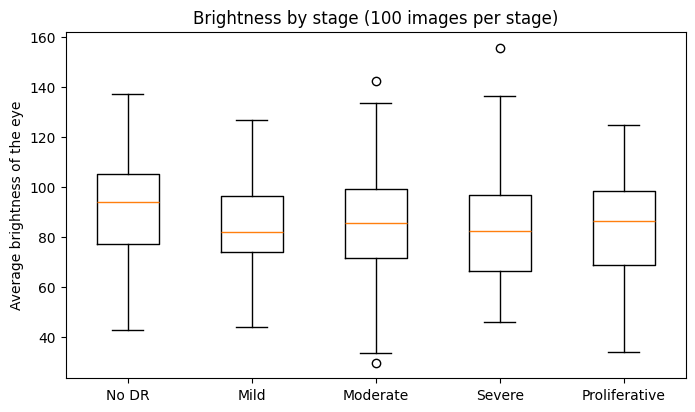

Median brightness per stage:
stage
No DR            94.000000
Mild             81.800003
Moderate         85.599998
Severe           82.400002
Proliferative    86.300003
Name: brightness, dtype: float32


In [ ]:
#cell 10
def retina_brightness(path):
    """Average brightness of the eye only (black border ignored)."""
    img = Image.open(path).convert('L')
    img.thumbnail((512, 512))
    arr = np.asarray(img, dtype=np.float32)
    return arr[arr > 10].mean()

# 100 random images from EACH stage, so small stages are fairly represented
strat = df.groupby('diagnosis').sample(100, random_state=42).copy()
strat['brightness'] = [retina_brightness(p) for p in strat['path']]  # takes 1-3 minutes

plt.figure(figsize=(8, 4.5))
plt.boxplot([strat.loc[strat['diagnosis'] == s, 'brightness'] for s in range(5)])
plt.xticks(range(1, 6), STAGES)
plt.ylabel('Average brightness of the eye'); plt.title('Brightness by stage (100 images per stage)')
save_fig('04b_brightness_by_stage'); plt.show()

print('Median brightness per stage:')
print(strat.groupby('stage')['brightness'].median().reindex(STAGES).round(1))

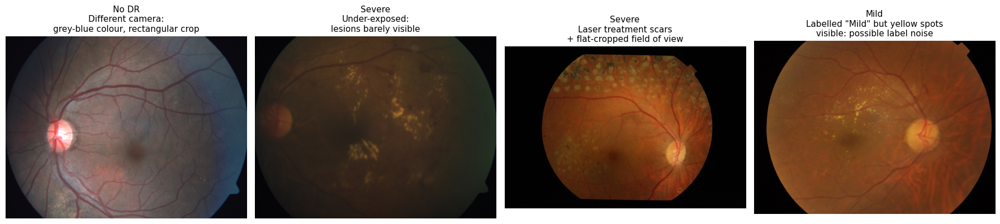

In [ ]:
#cell 11
def grid_image(stage, col):
    """Path of the image shown in Figure 02 at row=stage, column=col (same random seed = same image)."""
    return df[df['diagnosis'] == stage].sample(4, random_state=42)['path'].iloc[col]

# (stage, column in Figure 02, caption)
examples = [
    (0, 1, 'Different camera:\ngrey-blue colour, rectangular crop'),
    (3, 1, 'Under-exposed:\nlesions barely visible'),
    (3, 3, 'Laser treatment scars\n+ flat-cropped field of view'),
    (1, 3, 'Labelled "Mild" but yellow spots\nvisible: possible label noise'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (stage, col, caption) in zip(axes, examples):
    ax.imshow(Image.open(grid_image(stage, col)))
    ax.set_title(f'{STAGE_NAMES[stage]}\n{caption}', fontsize=11)
    ax.axis('off')
plt.tight_layout(); save_fig('05_dataset_challenges'); plt.show()

In [ ]:
# Same shortcut test for the yes/no task: can image size alone tell healthy from DR?
majority_bin = df.groupby('resolution')['has_dr'].agg(lambda s: s.mode()[0])
size_only_bin = (df['resolution'].map(majority_bin) == df['has_dr']).mean()
print(f'Healthy vs DR, always guessing "DR":  {df["has_dr"].mean():.1%}')
print(f'Healthy vs DR, from image size only:  {size_only_bin:.1%}')

# Save the resolution-by-stage table to Drive (useful for the report appendix)
ct.to_csv(os.path.join(RESULTS_DIR, 'resolution_by_stage.csv'))

Healthy vs DR, always guessing "DR":  50.7%
Healthy vs DR, from image size only:  90.5%


In [3]:
#start of preprocessing- stage 2
#cell 12
import cv2                                          # OpenCV: the main image-processing library
from concurrent.futures import ThreadPoolExecutor   # process several images at once (faster)
from tqdm.auto import tqdm                          # progress bar

WORK_SIZE = 512   # filters run at this size, so tiny lesions keep their detail
IMG_SIZE  = 224   # final size given to the CNN (EfficientNetB0's standard input size)
VERSIONS  = ['v0', 'v1', 'v2']

# Keep each image's resolution: needed for the "hard test" in Step 6
if 'resolution' not in df.columns:
    sizes = [Image.open(p).size for p in df['path']]
    df['resolution'] = [f'{w}x{h}' for w, h in sizes]

def grid_image(stage, col):
    """Path of the image shown in Figure 02 at row=stage, column=col."""
    return df[df['diagnosis'] == stage].sample(4, random_state=42)['path'].iloc[col]

In [4]:
#cell 13
BAND = 0.75   # <- REPLACE with the value printed by Cell 18 (fixed number = reproducible pipeline)

def load_rgb(path):
    """Read an image as RGB (OpenCV reads colours as BGR by default, so we convert)."""
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

def crop_to_retina(img, tol=10):
    """Remove the black border (simple threshold segmentation: brighter than 'tol' = eye)."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    rows = np.where(mask.mean(axis=1) > 0.01)[0]    # rows that are at least 1% eye
    cols = np.where(mask.mean(axis=0) > 0.01)[0]
    if len(rows) == 0 or len(cols) == 0:
        return img
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

def pad_to_square(img):
    """Add black bars so width == height (padding keeps the eye round; stretching would distort it)."""
    h, w = img.shape[:2]
    size = max(h, w)
    top, left = (size - h) // 2, (size - w) // 2
    return cv2.copyMakeBorder(img, top, size - h - top, left, size - w - left,
                              cv2.BORDER_CONSTANT, value=0)

def fov_mask(size, band=BAND, radius=0.95):
    """Common field of view: the SAME shape for every image (circle with flat top and bottom).
    Full-circle and flat-cut cameras end up identical, so shape no longer reveals the camera."""
    yy, xx = np.mgrid[:size, :size]
    c, r = (size - 1) / 2, size / 2
    circle = (xx - c) ** 2 + (yy - c) ** 2 <= (radius * r) ** 2
    flat   = np.abs(yy - c) <= band * r
    return (circle & flat).astype(np.uint8)

FOV = fov_mask(WORK_SIZE)   # built once, reused for every image

def geometry(img):
    """Stage A: crop, pad to square, resize to working size.
    Also returns a mask of real eye pixels inside the FOV (used by Ben Graham)."""
    img = pad_to_square(crop_to_retina(img))
    interp = cv2.INTER_AREA if img.shape[0] > WORK_SIZE else cv2.INTER_CUBIC
    img = cv2.resize(img, (WORK_SIZE, WORK_SIZE), interpolation=interp)
    eye = (cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) > 10).astype(np.uint8)
    return img, eye & FOV

def finish(img):
    """Stage C: apply the common FOV mask, then shrink to the CNN input size."""
    return cv2.resize(img * FOV[:, :, None], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

In [5]:
#cell 14
def denoise(img):
    """Noise removal with a bilateral filter: smooths noise but keeps edges sharp."""
    return cv2.bilateralFilter(img, d=5, sigmaColor=30, sigmaSpace=5)

def apply_clahe(img):
    """CLAHE contrast enhancement on brightness only (L channel of LAB), so lesion colours don't shift."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def unsharp_mask(img, sigma=2.0, amount=1.0):
    """Edge enhancement: sharpened = image + amount * (image - blurred image)."""
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 1 + amount, blur, -amount, 0)

def ben_graham(img, mask):
    """Ben Graham (2015): subtract the local average colour to remove lighting and camera tint.
    Improvement: the local average uses EYE pixels only (normalised convolution),
    so the black background can't create bright/dark stripes at the edges."""
    sigma = img.shape[0] / 60
    m = mask.astype(np.float32)
    f = img.astype(np.float32)
    local_sum   = cv2.GaussianBlur(f * m[:, :, None], (0, 0), sigma)  # blurred eye pixels only
    local_count = cv2.GaussianBlur(m, (0, 0), sigma)[:, :, None]      # how much eye was nearby
    local_mean  = local_sum / np.maximum(local_count, 1e-3)           # true average of eye pixels
    return np.clip(4 * f - 4 * local_mean + 128, 0, 255).astype(np.uint8)

def photometric(img, mask, version):
    """Stage B: colour/contrast processing for each version."""
    if version == 'v0':
        return img
    img = denoise(img)
    if version == 'v1':
        return unsharp_mask(apply_clahe(img))
    if version == 'v2':
        return ben_graham(img, mask)
    raise ValueError(f'Unknown version: {version}')

def preprocess(img, version='v2'):
    """Full pipeline. The demo app will reuse this exact function."""
    img, mask = geometry(img)
    return finish(photometric(img, mask, version))

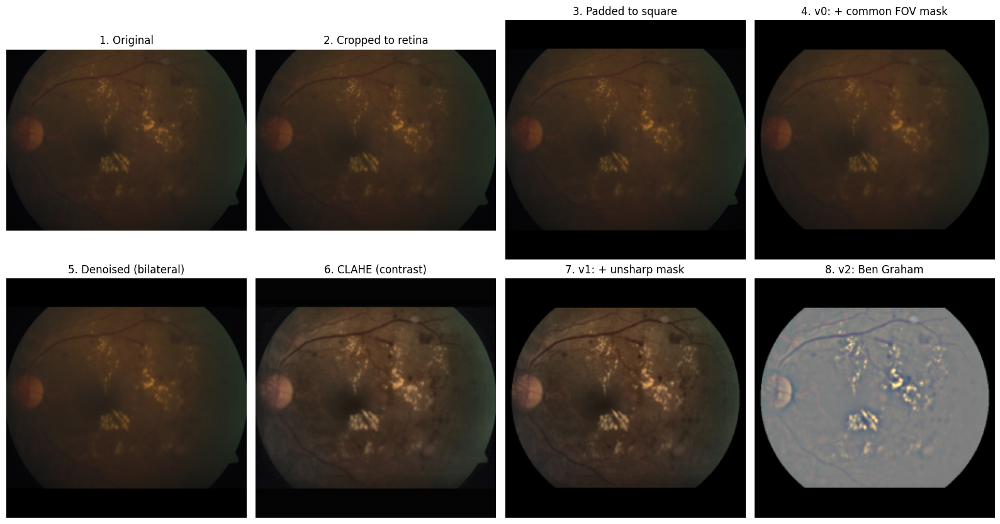

In [ ]:
#cell 15 - figure 06
img0    = load_rgb(grid_image(3, 1))   # the dark Severe image
cropped = crop_to_retina(img0)
square, mask = geometry(img0)
den     = denoise(square)
clahe   = apply_clahe(den)

steps = {
    '1. Original':              img0,
    '2. Cropped to retina':     cropped,
    '3. Padded to square':      square,
    '4. v0: + common FOV mask': finish(square),
    '5. Denoised (bilateral)':  den,
    '6. CLAHE (contrast)':      clahe,
    '7. v1: + unsharp mask':    finish(unsharp_mask(clahe)),
    '8. v2: Ben Graham':        finish(ben_graham(den, mask)),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (title, im) in zip(axes.flat, steps.items()):
    ax.imshow(im); ax.set_title(title, fontsize=12); ax.axis('off')
plt.tight_layout(); save_fig('06_pipeline_steps'); plt.show()


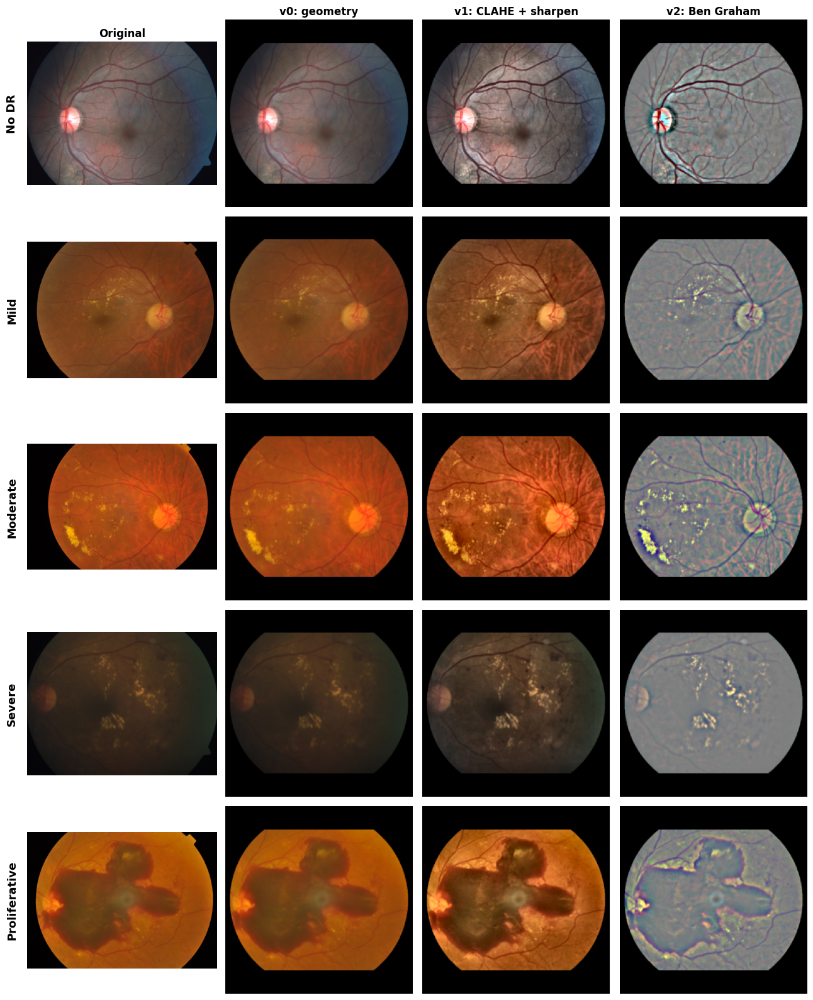

In [ ]:
#cell 16 - figure 07
picks = [(0, 1), (1, 3), (2, 3), (3, 1), (4, 1)]   # one image per stage, from Figure 02
titles = ['Original', 'v0: geometry', 'v1: CLAHE + sharpen', 'v2: Ben Graham']

fig, axes = plt.subplots(5, 4, figsize=(13, 16))
for r, (stage, col) in enumerate(picks):
    img = load_rgb(grid_image(stage, col))
    row = [img] + [preprocess(img, v) for v in VERSIONS]
    for c, im in enumerate(row):
        axes[r, c].imshow(im); axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(titles[c], fontsize=12, fontweight='bold')
    axes[r, 0].text(-0.05, 0.5, STAGE_NAMES[stage], transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='right', fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig('07_before_after_by_stage'); plt.show()

  0%|          | 0/3662 [00:00<?, ?it/s]

v0: saved 251 MB
v1: saved 302 MB
v2: saved 254 MB


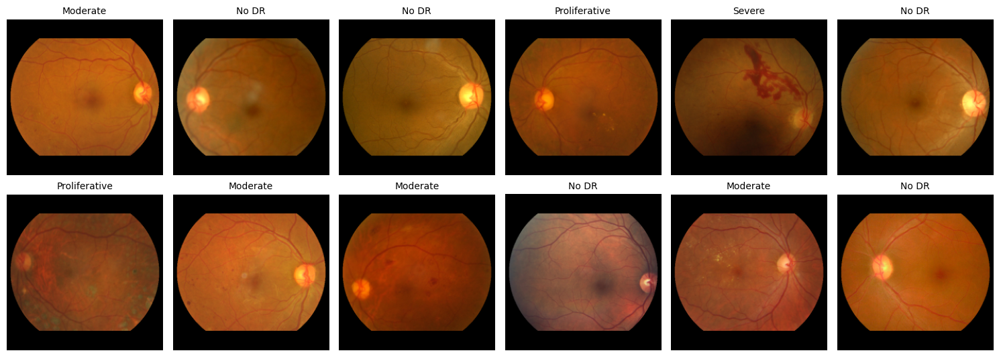

In [ ]:
#cell 17 - stage 2B - Clean all images and save to Drive
def process_one(path):
       """Load one image, run geometry ONCE, then make all 3 versions from it."""
       g, m = geometry(load_rgb(path))
       return [finish(photometric(g, m, v)) for v in VERSIONS]

N = len(df)
arrays = {v: np.zeros((N, IMG_SIZE, IMG_SIZE, 3), np.uint8) for v in VERSIONS}

# 4 images processed at the same time; results come back in the original order
with ThreadPoolExecutor(max_workers=4) as ex:
    for i, outs in enumerate(tqdm(ex.map(process_one, df['path']), total=N)):
        for v, out in zip(VERSIONS, outs):
            arrays[v][i] = out

# Save each version as ONE compressed file (Drive handles 1 big file far better than 3,662 small ones)
for v in VERSIONS:
    out_path = os.path.join(PROCESSED_DIR, f'{v}_{IMG_SIZE}.npz')
    np.savez_compressed(out_path, images=arrays[v], id_code=df['id_code'].values.astype(str))
    print(f'{v}: saved {os.path.getsize(out_path) / 1e6:.0f} MB')

df[['id_code', 'diagnosis', 'stage', 'resolution']].to_csv(
    os.path.join(PROCESSED_DIR, 'metadata.csv'), index=False)

# Quick check: 12 random processed images. Look for any that are black, off-centre or cut off
idx = np.random.default_rng(0).choice(N, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, i in zip(axes.flat, idx):
    ax.imshow(arrays['v0'][i]); ax.set_title(df['stage'].iloc[i], fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

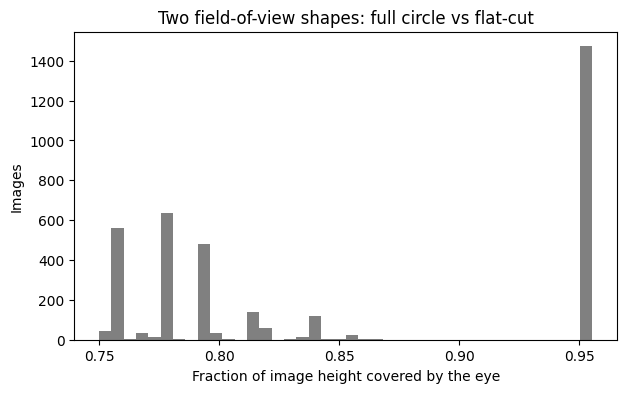

Stage mix (%) for flat-cut (False) vs full-circle (True) images:
stage        No DR  Mild  Moderate  Severe  Proliferative
full_circle                                              
False         19.0  16.0      44.0     9.0           13.0
True          95.0   1.0       3.0     0.0            1.0

Guess "healthy if full circle, DR if flat-cut": 86.9% accuracy (baseline 50.7%)
Suggested BAND (5th percentile of height fraction): 0.76


In [ ]:
#Cell 18
STAGES = list(STAGE_NAMES.values())

# If Colab restarted, reload the current v0 images from Drive
if 'arrays' not in globals():
    arrays = {'v0': np.load(os.path.join(PROCESSED_DIR, f'v0_{IMG_SIZE}.npz'))['images']}

# For each image: what fraction of its height is eye? (~0.95 = full circle, lower = flat-cut camera)
has_eye_row = (arrays['v0'].max(axis=3) > 10).any(axis=2)   # (N, 224): True for rows containing eye
df['height_frac'] = has_eye_row.sum(axis=1) / IMG_SIZE
df['full_circle'] = df['height_frac'] > 0.9

plt.figure(figsize=(7, 4))
plt.hist(df['height_frac'], bins=40, color='gray')
plt.xlabel('Fraction of image height covered by the eye'); plt.ylabel('Images')
plt.title('Two field-of-view shapes: full circle vs flat-cut')
plt.show()

print('Stage mix (%) for flat-cut (False) vs full-circle (True) images:')
print((pd.crosstab(df['full_circle'], df['stage'], normalize='index')[STAGES] * 100).round(0))
shape_acc = (df['full_circle'] == (df['has_dr'] == 0)).mean()
print(f'\nGuess "healthy if full circle, DR if flat-cut": {shape_acc:.1%} accuracy (baseline 50.7%)')
print(f'Suggested BAND (5th percentile of height fraction): {np.percentile(df["height_frac"], 5):.2f}')

v0: 268 MB, saved Mon Sep 28 10:07:00 2026
v1: 323 MB, saved Mon Sep 28 10:07:17 2026
v2: 281 MB, saved Mon Sep 28 10:07:35 2026


  0%|          | 0/3662 [00:00<?, ?it/s]

Shape-only accuracy (should match Cell 18): 86.9%


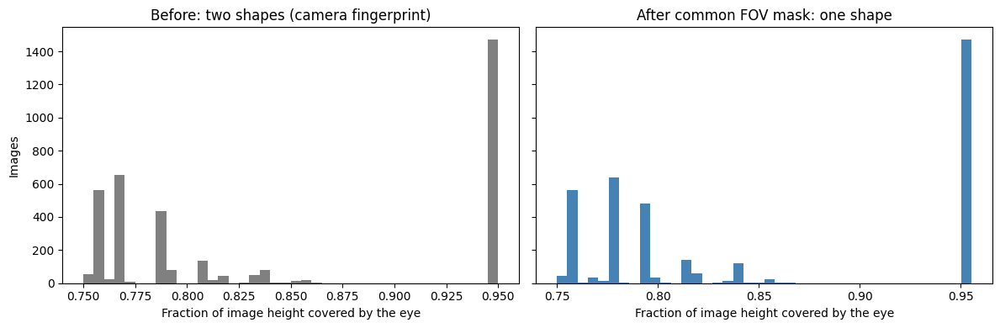

Images with the standard shape: 35.4%


In [ ]:
#cell 19
import time

# 1. Check that Cell 17 finished and saved the NEW files (Colab shows UTC time)
for v in VERSIONS:
    p = os.path.join(PROCESSED_DIR, f'{v}_{IMG_SIZE}.npz')
    print(f'{v}: {os.path.getsize(p) / 1e6:.0f} MB, saved {time.ctime(os.path.getmtime(p))}')

# 2. "After": load the new v0 images from Drive and measure their shape
v0_new = np.load(os.path.join(PROCESSED_DIR, f'v0_{IMG_SIZE}.npz'))['images']
height_after = (v0_new.max(axis=3) > 10).any(axis=2).sum(axis=1) / IMG_SIZE

# 3. "Before": recompute the old shape measure from the raw images
def shape_before(path):
    """Eye height relative to the square image, as the old pipeline produced it
    (capped at 0.95 because the old circular mask used 95% of the radius)."""
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE) > 10
    h = (mask.mean(axis=1) > 0.01).sum()   # rows containing eye
    w = (mask.mean(axis=0) > 0.01).sum()   # columns containing eye
    return min(h / max(h, w), 0.95)

with ThreadPoolExecutor(max_workers=4) as ex:        # about 3-5 minutes
    height_before = np.array(list(tqdm(ex.map(shape_before, df['path']), total=len(df))))

# Sanity check: this should match the shape accuracy Cell 18 printed earlier
full_circle = height_before > 0.9
print(f'Shape-only accuracy (should match Cell 18): {(full_circle == (df["has_dr"] == 0)).mean():.1%}')

# 4. Figure 08: before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(height_before, bins=40, color='gray')
axes[0].set_title('Before: two shapes (camera fingerprint)')
axes[1].hist(height_after, bins=40, color='steelblue')
axes[1].set_title('After common FOV mask: one shape')
for ax in axes:
    ax.set_xlabel('Fraction of image height covered by the eye')
axes[0].set_ylabel('Images')
plt.tight_layout(); save_fig('08_fov_shape_before_after'); plt.show()

print(f'Images with the standard shape: {(np.abs(height_after - BAND) < 0.03).mean():.1%}')

v0: 251 MB, saved Mon Sep 28 16:44:23 2026
v1: 302 MB, saved Mon Sep 28 16:44:51 2026
v2: 254 MB, saved Mon Sep 28 16:45:31 2026


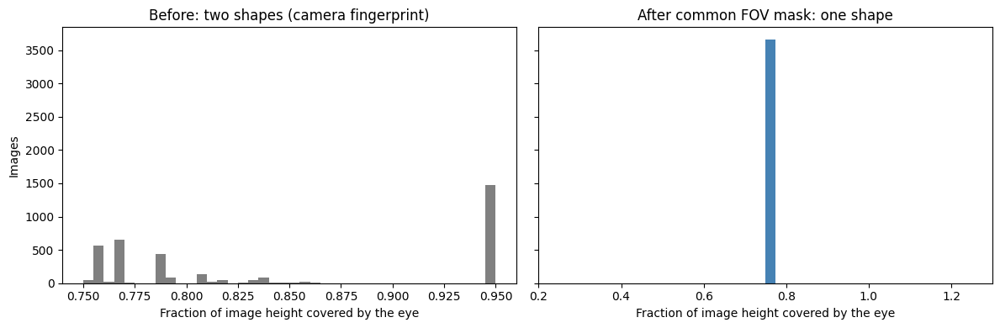

Images with the standard shape: 100.0%


In [ ]:
# Re-check after rerunning Cell 17 (reuses height_before from Cell 19)
for v in VERSIONS:
    p = os.path.join(PROCESSED_DIR, f'{v}_{IMG_SIZE}.npz')
    print(f'{v}: {os.path.getsize(p) / 1e6:.0f} MB, saved {time.ctime(os.path.getmtime(p))}')

# 'arrays' now holds the NEW images from Cell 17, so no need to load from Drive
height_after = (arrays['v0'].max(axis=3) > 10).any(axis=2).sum(axis=1) / IMG_SIZE

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(height_before, bins=40, color='gray')
axes[0].set_title('Before: two shapes (camera fingerprint)')
axes[1].hist(height_after, bins=40, color='steelblue')
axes[1].set_title('After common FOV mask: one shape')
for ax in axes:
    ax.set_xlabel('Fraction of image height covered by the eye')
axes[0].set_ylabel('Images')
plt.tight_layout(); save_fig('08_fov_shape_before_after'); plt.show()

print(f'Images with the standard shape: {(np.abs(height_after - BAND) < 0.03).mean():.1%}')

Camera ID baseline (always guess the biggest group): 26.6%

         brightness spread (std)  contrast (mean)  sharpness (mean)  \
version                                                               
v0                        21.033           16.514         37.009998   
v1                        17.145           21.247        263.337006   
v2                         0.212           14.312        270.085999   

         camera ID accuracy  
version                      
v0                    0.796  
v1                    0.765  
v2                    0.658  


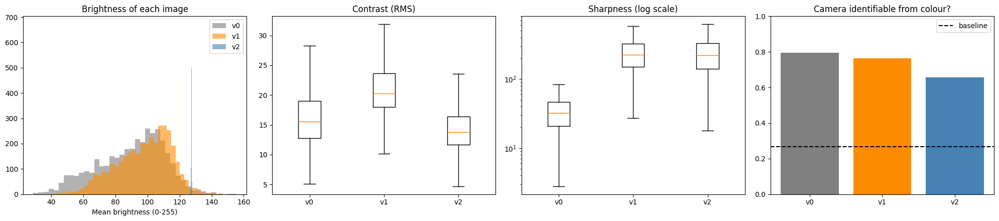

In [ ]:
#cell 20
# Cell 20 - Part 2C: prove the preprocessing improved image quality (with numbers)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Measure only well inside the eye: shrink the FOV mask by 3 pixels so its edge doesn't count
FOV_INNER = cv2.erode(fov_mask(IMG_SIZE), np.ones((7, 7), np.uint8)).astype(bool)
GRAY_W = np.array([0.299, 0.587, 0.114], np.float32)   # standard RGB -> brightness weights

def image_stats(X, batch=256):
    """Per-image measures inside the eye: mean/std of R,G,B, brightness, contrast, sharpness."""
    rows = []
    for s in range(0, len(X), batch):
        xb = X[s:s + batch].astype(np.float32)
        px = xb[:, FOV_INNER]                  # (batch, pixels, 3): eye pixels only
        gray = xb @ GRAY_W                     # (batch, 224, 224): brightness image
        g_in = gray[:, FOV_INNER]
        sharp = [cv2.Laplacian(g, cv2.CV_32F)[FOV_INNER].var() for g in gray]
        rows.append(np.column_stack([px.mean(1), px.std(1), g_in.mean(1), g_in.std(1), sharp]))
    cols = ['R', 'G', 'B', 'sd_R', 'sd_G', 'sd_B', 'brightness', 'contrast', 'sharpness']
    return pd.DataFrame(np.vstack(rows), columns=cols)

stats = {v: image_stats(arrays[v]) for v in VERSIONS}

# Camera fingerprint test: guess the camera (resolution group) from colour statistics only
counts = df['resolution'].value_counts()
camera = df['resolution'].where(df['resolution'].map(counts) >= 30, 'other').values  # merge tiny groups
colour_cols = ['R', 'G', 'B', 'sd_R', 'sd_G', 'sd_B']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
baseline = pd.Series(camera).value_counts(normalize=True).max()

summary = []
for v in VERSIONS:
    s = stats[v]
    summary.append({'version': v,
                    'brightness spread (std)': s['brightness'].std(),
                    'contrast (mean)': s['contrast'].mean(),
                    'sharpness (mean)': s['sharpness'].mean(),
                    'camera ID accuracy': cross_val_score(rf, s[colour_cols], camera, cv=cv).mean()})
summary = pd.DataFrame(summary).set_index('version').round(3)
summary.to_csv(os.path.join(RESULTS_DIR, 'preprocessing_quality.csv'))
print(f'Camera ID baseline (always guess the biggest group): {baseline:.1%}\n')
print(summary)

# Figure 09: the four measures side by side
colors = ['gray', 'darkorange', 'steelblue']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for v, c in zip(VERSIONS, colors):
    axes[0].hist(stats[v]['brightness'], bins=40, alpha=0.6, color=c, label=v)
axes[0].set_title('Brightness of each image'); axes[0].set_xlabel('Mean brightness (0-255)'); axes[0].legend()
axes[1].boxplot([stats[v]['contrast'] for v in VERSIONS], showfliers=False)
axes[1].set_xticks([1, 2, 3], VERSIONS); axes[1].set_title('Contrast (RMS)')
axes[2].boxplot([stats[v]['sharpness'] for v in VERSIONS], showfliers=False)
axes[2].set_xticks([1, 2, 3], VERSIONS); axes[2].set_yscale('log'); axes[2].set_title('Sharpness (log scale)')
axes[3].bar(VERSIONS, summary['camera ID accuracy'], color=colors)
axes[3].axhline(baseline, ls='--', color='black', label='baseline')
axes[3].set_ylim(0, 1); axes[3].set_title('Camera identifiable from colour?'); axes[3].legend()
plt.tight_layout(); save_fig('09_preprocessing_quality'); plt.show()

Candidate pairs (fingerprint differs by <= 10 bits): 23435
Confirmed near-duplicate pairs (correlation >= 0.95): 153
Duplicate groups: 136 (same label: 99, conflicting labels: 37)
Images removed: 181 -> 3481 images remain


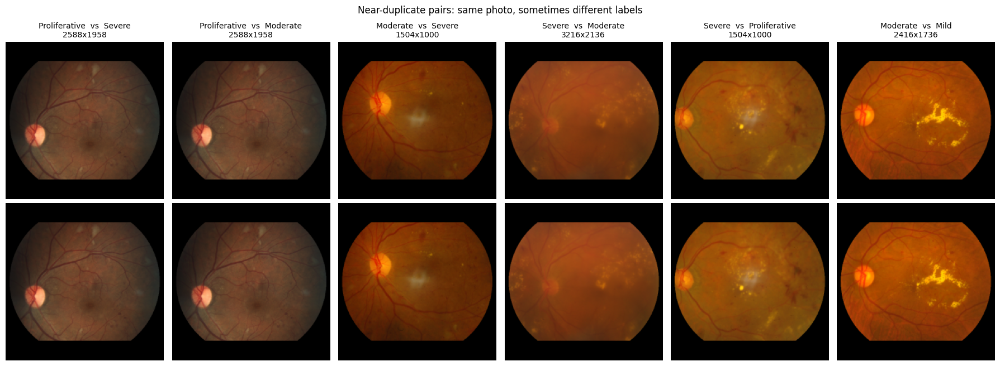

In [ ]:
#Cell 21: Find and handle duplicates
# Cell 21 - Part 2D (a): find near-duplicate images
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

C0, C1 = 40, 184   # central 144x144 square: fully inside the FOV, so the mask edge doesn't affect it
X0 = arrays['v0']

def phash64(img):
    """Perceptual hash: 64 yes/no bits describing the image's overall layout
    (robust to resizing and compression)."""
    g = cv2.cvtColor(img[C0:C1, C0:C1], cv2.COLOR_RGB2GRAY)
    g = cv2.resize(g, (32, 32), interpolation=cv2.INTER_AREA).astype(np.float32)
    low = cv2.dct(g)[:8, :8]                  # 8x8 lowest frequencies = overall layout
    bits = (low > np.median(low)).flatten()
    return int.from_bytes(np.packbits(bits).tobytes(), 'big')

hashes = np.array([phash64(im) for im in X0], dtype=np.uint64)

# Check 1: number of differing bits between every pair of fingerprints
dist = np.bitwise_count(hashes[:, None] ^ hashes[None, :])
cand = np.argwhere(np.triu(dist <= 10, k=1))   # candidate pairs (each pair once)

# Check 2: pixel correlation of the central region (true duplicates score ~1.0)
small = np.array([cv2.resize(cv2.cvtColor(im[C0:C1, C0:C1], cv2.COLOR_RGB2GRAY), (64, 64),
                             interpolation=cv2.INTER_AREA).flatten() for im in X0], np.float32)
small = (small - small.mean(1, keepdims=True)) / (small.std(1, keepdims=True) + 1e-6)
corr = np.array([small[i] @ small[j] / small.shape[1] for i, j in cand])
dups = cand[corr >= 0.95]
print(f'Candidate pairs (fingerprint differs by <= 10 bits): {len(cand)}')
print(f'Confirmed near-duplicate pairs (correlation >= 0.95): {len(dups)}')

# Group duplicates (if A=B and B=C, all three are one group)
N = len(df)
if len(dups):
    graph = coo_matrix((np.ones(len(dups)), (dups[:, 0], dups[:, 1])), shape=(N, N))
    _, group_id = connected_components(graph, directed=False)
else:
    group_id = np.arange(N)
df['dup_group'] = group_id
in_dup = df[df['dup_group'].map(df['dup_group'].value_counts()) > 1]

# Same label -> keep one copy. Different labels -> labels unreliable, remove all copies
drop, n_agree, n_conflict = [], 0, 0
for _, grp in in_dup.groupby('dup_group'):
    if grp['diagnosis'].nunique() == 1:
        drop += list(grp.index[1:]); n_agree += 1
    else:
        drop += list(grp.index); n_conflict += 1
print(f'Duplicate groups: {n_agree + n_conflict} (same label: {n_agree}, conflicting labels: {n_conflict})')
print(f'Images removed: {len(drop)} -> {N - len(drop)} images remain')
in_dup[['id_code', 'stage', 'resolution', 'dup_group']].sort_values('dup_group').to_csv(
    os.path.join(RESULTS_DIR, 'duplicates.csv'), index=False)

# Figure 10: example duplicate pairs, conflicting labels shown first
if len(dups):
    order = sorted(dups.tolist(), key=lambda p: df['diagnosis'].iloc[p[0]] == df['diagnosis'].iloc[p[1]])
show = order[:6]   # conflicting-label pairs first
fig, axes = plt.subplots(2, len(show), figsize=(3 * len(show), 6.8), squeeze=False)
for k, (i, j) in enumerate(show):
    axes[0, k].set_title(f"{df['stage'].iloc[i]}  vs  {df['stage'].iloc[j]}\n{df['resolution'].iloc[i]}",
                         fontsize=10)
    for r, ix in enumerate((i, j)):
        axes[r, k].imshow(arrays['v0'][ix]); axes[r, k].axis('off')
plt.suptitle('Near-duplicate pairs: same photo, sometimes different labels', fontsize=12)
plt.tight_layout(); save_fig('10_duplicate_pairs'); plt.show()

stage    No DR  Mild  Moderate  Severe  Proliferative  Total
split                                                       
train     1253   237       644     117            185   2436
val        269    50       138      25             40    522
test       269    51       139      25             39    523
removed     14    32        78      26             31    181

"Hard test" size: 156 images
stage
No DR            32
Mild             39
Moderate         53
Severe           13
Proliferative    19
Name: count, dtype: int64


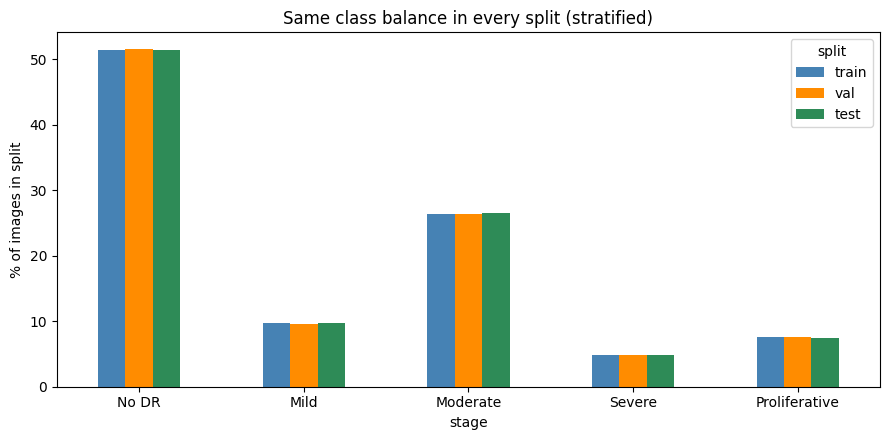


Saved metadata.csv with the split.


In [ ]:
# Cell 22 - Part 2D (b): stratified 70/15/15 train/validation/test split
from sklearn.model_selection import train_test_split
STAGES = list(STAGE_NAMES.values())          # stage names in order (was defined in Cells 9/18)
df['has_dr'] = (df['diagnosis'] > 0).astype(int)   # make sure the yes/no label exists before saving
clean_idx = df.index.difference(drop)
train_idx, temp_idx = train_test_split(clean_idx, test_size=0.30, random_state=42,
                                       stratify=df.loc[clean_idx, 'diagnosis'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42,
                                     stratify=df.loc[temp_idx, 'diagnosis'])
df['split'] = 'removed'
df.loc[train_idx, 'split'] = 'train'
df.loc[val_idx, 'split'] = 'val'
df.loc[test_idx, 'split'] = 'test'

# Table for the report: images per stage in each split
table = (pd.crosstab(df['split'], df['stage'])[STAGES]
         .reindex(['train', 'val', 'test', 'removed']).fillna(0).astype(int))
table['Total'] = table.sum(axis=1)
print(table)

# How big will the "hard test" be? (test images from the two mixed-camera groups)
MIXED = ['2416x1736', '2588x1958']
hard = df[(df['split'] == 'test') & df['resolution'].isin(MIXED)]
print(f'\n"Hard test" size: {len(hard)} images')
print(hard['stage'].value_counts().reindex(STAGES).fillna(0).astype(int))

# Figure 11: class balance per split (should look the same in all three)
pct = pd.crosstab(df['split'], df['stage'], normalize='index')[STAGES].reindex(['train', 'val', 'test']) * 100
pct.T.plot(kind='bar', figsize=(9, 4.5), color=['steelblue', 'darkorange', 'seagreen'])
plt.ylabel('% of images in split'); plt.title('Same class balance in every split (stratified)')
plt.xticks(rotation=0); plt.tight_layout(); save_fig('11_split_distribution'); plt.show()

# Save the final metadata (labels + split) to Drive: every later step reads this
df[['id_code', 'diagnosis', 'stage', 'has_dr', 'resolution', 'split']].to_csv(
    os.path.join(PROCESSED_DIR, 'metadata.csv'), index=False)
print('\nSaved metadata.csv with the split.')


In [ ]:
#cell 20b
# Test colour tint (mean R,G,B) and detail level (std R,G,B) separately
for name, cols in [('colour tint (means)', ['R', 'G', 'B']),
                   ('detail level (stds)', ['sd_R', 'sd_G', 'sd_B'])]:
    accs = [cross_val_score(rf, stats[v][cols], camera, cv=cv).mean() for v in VERSIONS]
    print(f'{name:22s}  v0: {accs[0]:.1%}   v1: {accs[1]:.1%}   v2: {accs[2]:.1%}')

colour tint (means)     v0: 65.0%   v1: 65.6%   v2: 51.5%
detail level (stds)     v0: 55.4%   v1: 56.4%   v2: 55.2%


In [6]:
# Cell 23 - Step 3: setup, augmentation and data pipeline
import tensorflow as tf
import keras
from keras import layers
from sklearn.utils.class_weight import compute_class_weight

SEED, BATCH, NUM_CLASSES = 42, 32, 5
keras.utils.set_random_seed(SEED)   # same random numbers every run (Python, NumPy, TensorFlow)
AUTOTUNE = tf.data.AUTOTUNE
STAGES = list(STAGE_NAMES.values())

idx = {s: np.where(df['split'].values == s)[0] for s in ['train', 'val', 'test']}
y_all = df['diagnosis'].values

# Geometric augmentation: orientation and zoom don't change the diagnosis
geo_aug = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical', seed=SEED),     # left/right eyes are mirror images
    layers.RandomRotation(0.5, fill_mode='constant', fill_value=0.0, seed=SEED),  # any angle (±180°)
    layers.RandomZoom(0.1, fill_mode='constant', fill_value=0.0, seed=SEED),      # ±10% magnification
], name='geometric_aug')

# Photometric augmentation: small exposure changes, like different camera settings
photo_aug = keras.Sequential([
    layers.RandomBrightness(0.1, value_range=(0, 255), seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
], name='photometric_aug')

def augment(x, y):
    """Random geometric changes, then small exposure changes; background kept black."""
    x = geo_aug(x, training=True)
    eye = tf.cast(tf.reduce_max(x, axis=-1, keepdims=True) > 0, x.dtype)  # where the eye is
    x = photo_aug(x, training=True) * eye       # brightness change must not light up the background
    return x, y

def make_ds(split, version, augment_on=False, balance=None, shuffle=False):
    """Build the data pipeline for one split.
    balance=None: natural class mix.  balance='oversample': every class equally often."""
    X, y = arrays[version][idx[split]], y_all[idx[split]]
    if balance == 'oversample':
        # One endless stream per class, sampled with equal probability -> balanced batches
        streams = [tf.data.Dataset.from_tensor_slices((X[y == c], y[y == c]))
                   .shuffle(2000, seed=SEED).repeat() for c in range(NUM_CLASSES)]
        ds = tf.data.Dataset.sample_from_datasets(streams, weights=[1 / NUM_CLASSES] * NUM_CLASSES,
                                                  seed=SEED).take(len(y))  # 1 epoch = train set size
    else:
        ds = tf.data.Dataset.from_tensor_slices((X, y))
        if shuffle:
            ds = ds.shuffle(len(y), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    if augment_on:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)     # prepare the next batch while the GPU trains on this one

# Class weights: mistakes on rare classes count more ("balanced" = inversely proportional to count)
train_counts = np.bincount(y_all[idx['train']], minlength=NUM_CLASSES)
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_all[idx['train']])
CLASS_WEIGHT = dict(enumerate(cw))
print(pd.DataFrame({'train images': train_counts, 'class weight': cw.round(2)}, index=STAGES))

# Sanity check: one augmented batch
xb, yb = next(iter(make_ds('train', 'v1', augment_on=True, shuffle=True)))
print(f'\nBatch: {xb.shape}, {xb.dtype}, pixel range {float(tf.reduce_min(xb)):.0f}-{float(tf.reduce_max(xb)):.0f}')

               train images  class weight
No DR                  1253          0.39
Mild                    237          2.06
Moderate                644          0.76
Severe                  117          4.16
Proliferative           185          2.63

Batch: (32, 224, 224, 3), <dtype: 'float32'>, pixel range 0-255


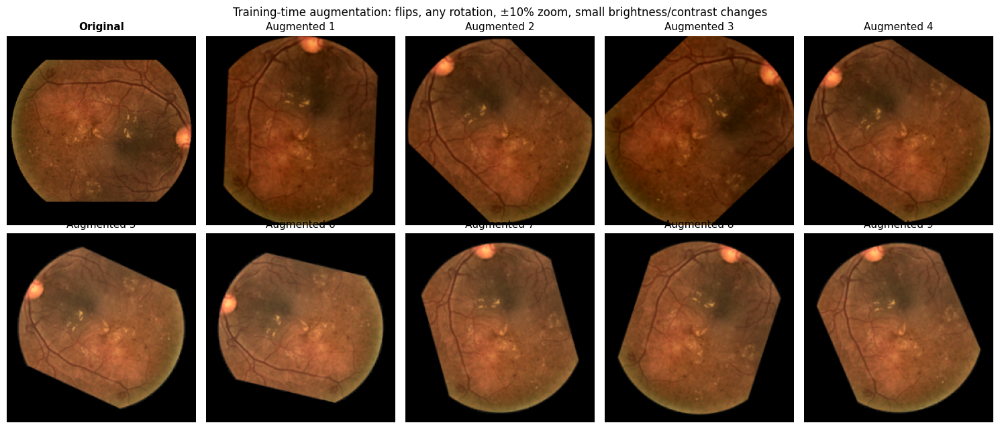

In [ ]:
#Cell 24: What augmentation looks like (Figure 12)
# One Moderate training image, augmented 9 different ways
i = idx['train'][np.where(y_all[idx['train']] == 2)[0][0]]
x10 = tf.cast(np.repeat(arrays['v1'][i][None], 10, axis=0), tf.float32)
aug10, _ = augment(x10, None)

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for k, ax in enumerate(axes.flat):
    img = x10[0] if k == 0 else aug10[k]
    ax.imshow(np.clip(img.numpy(), 0, 255).astype(np.uint8)); ax.axis('off')
    ax.set_title('Original' if k == 0 else f'Augmented {k}', fontsize=11,
                 fontweight='bold' if k == 0 else 'normal')
plt.suptitle('Training-time augmentation: flips, any rotation, ±10% zoom, small brightness/contrast changes',
             fontsize=12)
plt.tight_layout(); save_fig('12_augmentation_examples'); plt.show()

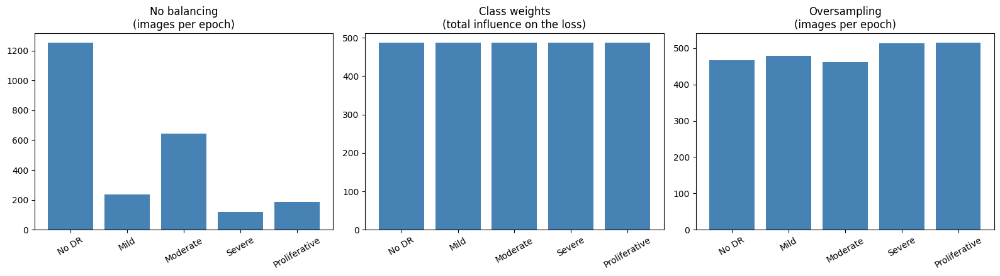

Oversampled epoch counts: {'No DR': np.int64(466), 'Mild': np.int64(479), 'Moderate': np.int64(462), 'Severe': np.int64(514), 'Proliferative': np.int64(515)}


In [ ]:
#Cell 25: The three ways of handling imbalance (Figure 13)
# Count what the model "sees" in one epoch under each strategy
ds_os = make_ds('train', 'v0', balance='oversample')
os_counts = np.bincount(np.concatenate([yb.numpy() for _, yb in ds_os]), minlength=NUM_CLASSES)
effective = train_counts * cw     # class weights: count x weight = each class's total influence on the loss

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, vals, title in [(axes[0], train_counts, 'No balancing\n(images per epoch)'),
                        (axes[1], effective, 'Class weights\n(total influence on the loss)'),
                        (axes[2], os_counts, 'Oversampling\n(images per epoch)')]:
    ax.bar(STAGES, vals, color='steelblue')
    ax.set_title(title); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); save_fig('13_imbalance_strategies'); plt.show()
print('Oversampled epoch counts:', dict(zip(STAGES, os_counts)))

In [7]:
#Cell 26: Model builder and experiment runner
# Cell 26 - Step 4A: model, metrics and experiment runner
import gc, time
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score

print('GPU:', tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    keras.mixed_precision.set_global_policy('mixed_float16')   # GPU: ~2x faster with tensor cores
else:
    keras.mixed_precision.set_global_policy('float32')         # CPU: mixed precision would be slower
    print('No GPU: running on CPU (fine for testing, too slow for real training)')

y_val = y_all[idx['val']]
EXP_LOG = os.path.join(RESULTS_DIR, 'experiments.csv')

def build_model(backbone='efficientnetb0', dropout=0.3):
    """Pretrained ImageNet backbone (frozen at first) + new classification head for 5 DR stages."""
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    shape = (IMG_SIZE, IMG_SIZE, 3)
    if backbone == 'efficientnetb0':
        base = keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=shape)
        x = inputs                                                     # rescales 0-255 input itself
    elif backbone == 'resnet50':
        base = keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=shape)
        x = keras.applications.resnet50.preprocess_input(inputs)       # RGB->BGR, subtract ImageNet mean
    elif backbone == 'mobilenetv2':
        base = keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=shape)
        x = keras.applications.mobilenet_v2.preprocess_input(inputs)   # scale to [-1, 1]
    else:
        raise ValueError(f'Unknown backbone: {backbone}')
    base.trainable = False
    x = base(x, training=False)          # BatchNorm stays in inference mode, even after unfreezing
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs, name=backbone), base

def evaluate(model, ds, y_true):
    """Kappa, macro-F1 and accuracy for the 5 stages, plus F1/accuracy for healthy vs DR."""
    probs = model.predict(ds, verbose=0)
    pred = probs.argmax(1)
    return {'qwk': cohen_kappa_score(y_true, pred, weights='quadratic'),
            'macro_f1': f1_score(y_true, pred, average='macro'),
            'accuracy': accuracy_score(y_true, pred),
            'binary_f1': f1_score(y_true > 0, pred > 0),
            'binary_acc': accuracy_score(y_true > 0, pred > 0)}, probs

class ValMetrics(keras.callbacks.Callback):
    """After every epoch: compute kappa and macro-F1 on the validation set and add them to the logs,
    so early stopping and learning-rate scheduling can use them."""
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val
    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(self.val_ds, verbose=0).argmax(1)
        logs['val_qwk'] = cohen_kappa_score(self.y_val, pred, weights='quadratic')
        logs['val_macro_f1'] = f1_score(self.y_val, pred, average='macro')

def run_experiment(name, version, backbone='efficientnetb0', balance='class_weight',
                   warmup_epochs=5, finetune_epochs=12, unfreeze_frac=0.3,
                   lr_head=1e-3, lr_ft=1e-4, patience=4, save_model=False):
    """Train one configuration (head, then fine-tune) and append its validation results to the log."""
    if os.path.exists(EXP_LOG) and name in pd.read_csv(EXP_LOG)['name'].values:
        print(f'{name}: already done, skipping'); return None
    keras.backend.clear_session(); gc.collect()
    keras.utils.set_random_seed(SEED)
    t0 = time.time()
    print(f'\n===== {name}: version={version}, backbone={backbone}, balance={balance} =====')

    train_ds = make_ds('train', version, augment_on=True, shuffle=True,
                       balance='oversample' if balance == 'oversample' else None)
    val_ds = make_ds('val', version)
    cw = CLASS_WEIGHT if balance == 'class_weight' else None
    model, base = build_model(backbone)
    metrics_cb = ValMetrics(val_ds, y_val)

    # Phase 1: train only the new head (backbone frozen)
    model.compile(keras.optimizers.Adam(lr_head), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=warmup_epochs, class_weight=cw,
                   callbacks=[metrics_cb], verbose=2)

    # Phase 2: unfreeze the top part of the backbone, fine-tune with a 10x smaller learning rate
    base.trainable = True
    for layer in base.layers[:int(len(base.layers) * (1 - unfreeze_frac))]:
        layer.trainable = False
    model.compile(keras.optimizers.Adam(lr_ft), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    callbacks = [metrics_cb,
                 keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=patience,
                                               restore_best_weights=True),
                 keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=0.3,
                                                   patience=2, min_lr=1e-6)]
    if save_model:
        callbacks.append(keras.callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, f'{name}.keras'),
                                                         monitor='val_qwk', mode='max', save_best_only=True))
    h2 = model.fit(train_ds, validation_data=val_ds, initial_epoch=warmup_epochs,
                   epochs=warmup_epochs + finetune_epochs, class_weight=cw, callbacks=callbacks, verbose=2)

    # Save the training history (for loss/accuracy curves) and the validation results
    hist = pd.concat([pd.DataFrame(h1.history).assign(phase='head'),
                      pd.DataFrame(h2.history).assign(phase='finetune')], ignore_index=True)
    hist.to_csv(os.path.join(RESULTS_DIR, f'history_{name}.csv'), index_label='epoch')
    res, _ = evaluate(model, val_ds, y_val)
    row = {'name': name, 'version': version, 'backbone': backbone, 'balance': balance,
           **{k: round(float(v), 4) for k, v in res.items()},
           'minutes': round((time.time() - t0) / 60, 1)}
    pd.DataFrame([row]).to_csv(EXP_LOG, mode='a', header=not os.path.exists(EXP_LOG), index=False)
    print(row)
    return model

# Quick check: all three backbones build (downloads ImageNet weights the first time)
for bb in ['efficientnetb0', 'resnet50', 'mobilenetv2']:
    m, b = build_model(bb)
    print(f'{bb:15s} parameters: {m.count_params() / 1e6:.1f}M   backbone layers: {len(b.layers)}')
keras.backend.clear_session()

GPU: []
No GPU: running on CPU (fine for testing, too slow for real training)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
efficientnetb0  parameters: 4.1M   backbone layers: 238
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
resnet50        parameters: 23.6M   backbone layers: 175
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mobilenetv2     parameters: 2.3M   backbone layers: 154


In [ ]:
#Cell 26b: Smoke test
# Tiny 2-epoch run to catch errors before the hour-long experiments
run_experiment('SMOKE', 'v0', warmup_epochs=1, finetune_epochs=1)
log = pd.read_csv(EXP_LOG)
log[log['name'] != 'SMOKE'].to_csv(EXP_LOG, index=False)   # remove the test row from the log
print('Smoke test passed.')


===== SMOKE: version=v0, backbone=efficientnetb0, balance=class_weight =====
77/77 - 112s - 1s/step - accuracy: 0.4696 - loss: 1.4423 - val_accuracy: 0.6437 - val_loss: 1.0155 - val_qwk: 0.7329 - val_macro_f1: 0.4593
Epoch 2/2
77/77 - 118s - 2s/step - accuracy: 0.5653 - loss: 1.2395 - val_accuracy: 0.7146 - val_loss: 0.7936 - val_qwk: 0.7532 - val_macro_f1: 0.5261 - learning_rate: 1.0000e-04
{'name': 'SMOKE', 'version': 'v0', 'backbone': 'efficientnetb0', 'balance': 'class_weight', 'qwk': 0.7532, 'macro_f1': 0.5261, 'accuracy': 0.7146, 'binary_f1': 0.9073, 'binary_acc': 0.908, 'minutes': 3.9}
Smoke test passed.


In [ ]:
# Cell 26c - memory fix: keep only the image version still needed, and build datasets once
import gc
log = pd.read_csv(EXP_LOG)
keep = log[log['name'].str.startswith('E1')].sort_values('qwk', ascending=False)['version'].iloc[0]
for v in list(arrays):
    if v != keep:
        del arrays[v]          # remaining experiments only use the E1 winner
gc.collect()
print('Keeping only', keep, 'in memory')

_BASE = {}   # cache: each source dataset is created once and reused by every experiment

def _base(split, version, cls=None):
    """Create the source dataset for a split (optionally one class) only the first time it's needed."""
    key = (split, version, cls)
    if key not in _BASE:
        sel = idx[split] if cls is None else idx[split][y_all[idx[split]] == cls]
        _BASE[key] = tf.data.Dataset.from_tensor_slices((arrays[version][sel], y_all[sel]))
    return _BASE[key]

def make_ds(split, version, augment_on=False, balance=None, shuffle=False):
    """Same pipeline as Cell 23, but without re-copying the images for every experiment."""
    n = len(idx[split])
    if balance == 'oversample':
        streams = [_base(split, version, c).shuffle(2000, seed=SEED).repeat() for c in range(NUM_CLASSES)]
        ds = tf.data.Dataset.sample_from_datasets(streams, weights=[1 / NUM_CLASSES] * NUM_CLASSES,
                                                  seed=SEED).take(n)
    else:
        ds = _base(split, version)
        if shuffle:
            ds = ds.shuffle(n, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    if augment_on:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

Keeping only v2 in memory


E1_v0: already done, skipping
E1_v1: already done, skipping
E1_v2: already done, skipping

>>> E1 winner (highest validation kappa): v2
E2_none: already done, skipping

===== E2_oversample: version=v2, backbone=efficientnetb0, balance=oversample =====
Epoch 1/5
77/77 - 112s - 1s/step - accuracy: 0.3670 - loss: 1.4671 - val_accuracy: 0.6322 - val_loss: 1.0353 - val_qwk: 0.7405 - val_macro_f1: 0.4654
Epoch 2/5
77/77 - 30s - 390ms/step - accuracy: 0.4733 - loss: 1.2457 - val_accuracy: 0.6494 - val_loss: 0.9285 - val_qwk: 0.7697 - val_macro_f1: 0.4894
Epoch 3/5
77/77 - 40s - 515ms/step - accuracy: 0.5000 - loss: 1.1847 - val_accuracy: 0.6418 - val_loss: 0.8787 - val_qwk: 0.7738 - val_macro_f1: 0.4703
Epoch 4/5
77/77 - 30s - 385ms/step - accuracy: 0.5353 - loss: 1.1284 - val_accuracy: 0.6686 - val_loss: 0.8212 - val_qwk: 0.7840 - val_macro_f1: 0.4982
Epoch 5/5
77/77 - 29s - 378ms/step - accuracy: 0.5493 - loss: 1.1066 - val_accuracy: 0.6648 - val_loss: 0.7950 - val_qwk: 0.7714 - val_macro_f

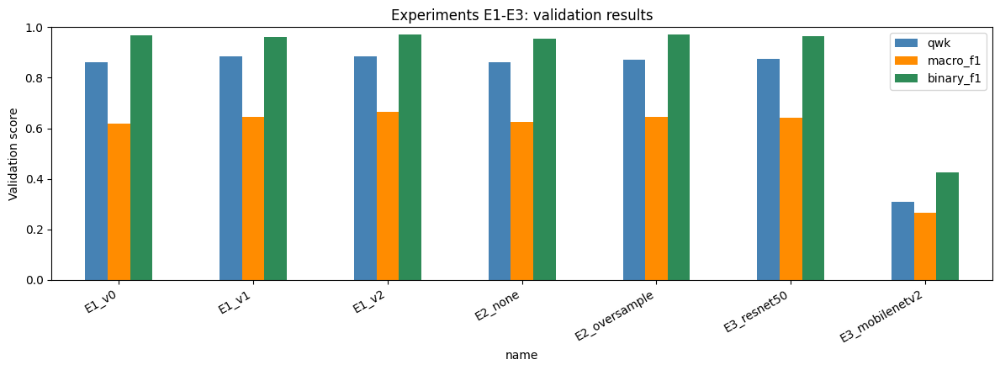

In [ ]:
# Cell 27 - Step 4B: experiments E1-E3. Each result is saved immediately; rerunning skips finished ones.

# E1: which preprocessing version works best? (EfficientNetB0 + class weights)
for v in VERSIONS:
    run_experiment(f'E1_{v}', version=v)
log = pd.read_csv(EXP_LOG)
best_version = log[log['name'].str.startswith('E1')].sort_values('qwk', ascending=False)['version'].iloc[0]
print(f'\n>>> E1 winner (highest validation kappa): {best_version}')

# E2: which imbalance strategy works best? (class weights were already tested in E1)
run_experiment('E2_none', version=best_version, balance='none')
run_experiment('E2_oversample', version=best_version, balance='oversample')
log = pd.read_csv(EXP_LOG)
cands = log[(log['version'] == best_version) & (log['backbone'] == 'efficientnetb0')]
best_balance = cands.sort_values('qwk', ascending=False)['balance'].iloc[0]
print(f'\n>>> E2 winner: {best_balance}')

# E3: which backbone works best? (using the winners of E1 and E2)
for bb in ['resnet50', 'mobilenetv2']:
    run_experiment(f'E3_{bb}', version=best_version, backbone=bb, balance=best_balance)

# Results table + Figure 14
log = pd.read_csv(EXP_LOG).set_index('name')
print(log.to_string())
ax = log[['qwk', 'macro_f1', 'binary_f1']].plot(kind='bar', figsize=(12, 4.5), ylim=(0, 1),
                                                color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('Validation score'); ax.set_title('Experiments E1-E3: validation results')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); save_fig('14_experiment_comparison'); plt.show()

In [ ]:
# Cell 28 - Step 4C: E4 final model: longer training + small hyperparameter search (models saved)
import shutil

log = pd.read_csv(EXP_LOG)
screen = log[log['name'].str.match(r'E[123]_')]
best = screen.sort_values('qwk', ascending=False).iloc[0]
cfg = dict(version=best['version'], backbone=best['backbone'], balance=best['balance'])
print('Best configuration from E1-E3:', cfg)

# (name, fraction of backbone unfrozen, fine-tuning learning rate)
E4_GRID = [('E4_top30_lr1e-4', 0.3, 1e-4),
           ('E4_all_lr1e-4',   1.0, 1e-4),
           ('E4_all_lr3e-5',   1.0, 3e-5)]
for name, frac, lr in E4_GRID:
    run_experiment(name, **cfg, warmup_epochs=5, finetune_epochs=25, unfreeze_frac=frac,
                   lr_ft=lr, patience=6, save_model=True)

# Pick the best E4 model on validation kappa and save it as the final model
log = pd.read_csv(EXP_LOG)
e4 = log[log['name'].str.startswith('E4')].sort_values('qwk', ascending=False)
print(e4.to_string(index=False))
winner = e4['name'].iloc[0]
shutil.copy(os.path.join(MODEL_DIR, f'{winner}.keras'), os.path.join(MODEL_DIR, 'final_model.keras'))
with open(os.path.join(MODEL_DIR, 'final_model.txt'), 'w') as f:
    f.write(f'{winner}\n{cfg}\n')
print(f'\n>>> Final model: {winner}, saved as models/final_model.keras')

Best configuration from E1-E3: {'version': 'v2', 'backbone': 'efficientnetb0', 'balance': 'class_weight'}

===== E4_top30_lr1e-4: version=v2, backbone=efficientnetb0, balance=class_weight =====
Epoch 1/5
77/77 - 91s - 1s/step - accuracy: 0.4265 - loss: 1.5158 - val_accuracy: 0.6092 - val_loss: 1.0675 - val_qwk: 0.7520 - val_macro_f1: 0.4383
Epoch 2/5
77/77 - 30s - 388ms/step - accuracy: 0.5837 - loss: 1.2826 - val_accuracy: 0.6954 - val_loss: 0.9034 - val_qwk: 0.7627 - val_macro_f1: 0.4904
Epoch 3/5
77/77 - 28s - 369ms/step - accuracy: 0.6190 - loss: 1.1948 - val_accuracy: 0.6073 - val_loss: 0.9521 - val_qwk: 0.7303 - val_macro_f1: 0.4578
Epoch 4/5
77/77 - 28s - 370ms/step - accuracy: 0.6289 - loss: 1.1517 - val_accuracy: 0.7261 - val_loss: 0.7798 - val_qwk: 0.7844 - val_macro_f1: 0.5463
Epoch 5/5
77/77 - 28s - 362ms/step - accuracy: 0.6260 - loss: 1.1369 - val_accuracy: 0.6743 - val_loss: 0.8596 - val_qwk: 0.7887 - val_macro_f1: 0.5115
Epoch 6/30
77/77 - 105s - 1s/step - accuracy: 0.6

In [ ]:
# Cell 28b - finalise: choose the best completed E4 model (no training needed, works on CPU)
import os, shutil, pandas as pd

EXP_LOG = os.path.join(RESULTS_DIR, 'experiments.csv')
log = pd.read_csv(EXP_LOG)
e4 = log[log['name'].str.startswith('E4')].sort_values('qwk', ascending=False)
row = e4.iloc[0]
winner = row['name']

src = os.path.join(MODEL_DIR, f'{winner}.keras')
assert os.path.exists(src), f'Model file missing: {src}'
shutil.copy(src, os.path.join(MODEL_DIR, 'final_model.keras'))
with open(os.path.join(MODEL_DIR, 'final_model.txt'), 'w') as f:
    f.write(f"{winner}\nversion={row['version']}, backbone={row['backbone']}, balance={row['balance']}\n")

print(log.to_string(index=False))
print(f"\n>>> Final model: {winner} (validation kappa {row['qwk']:.4f}), "
      f"saved as models/final_model.keras ({os.path.getsize(src) / 1e6:.1f} MB)")

           name version       backbone      balance    qwk  macro_f1  accuracy  binary_f1  binary_acc  minutes
          E1_v0      v0 efficientnetb0 class_weight 0.8629    0.6179    0.7778     0.9667      0.9674     12.1
          E1_v1      v1 efficientnetb0 class_weight 0.8846    0.6461    0.7912     0.9612      0.9617     10.0
          E1_v2      v2 efficientnetb0 class_weight 0.8855    0.6640    0.8084     0.9704      0.9713     12.0
        E2_none      v2 efficientnetb0         none 0.8611    0.6248    0.8123     0.9551      0.9579     12.3
  E2_oversample      v2 efficientnetb0   oversample 0.8715    0.6446    0.7874     0.9702      0.9713     11.1
    E3_resnet50      v2       resnet50 class_weight 0.8751    0.6409    0.7835     0.9646      0.9655     11.4
 E3_mobilenetv2      v2    mobilenetv2 class_weight 0.3085    0.2669    0.5881     0.4237      0.6456      7.0
E4_top30_lr1e-4      v2 efficientnetb0 class_weight 0.8956    0.6660    0.7950     0.9644      0.9655     12.2
 

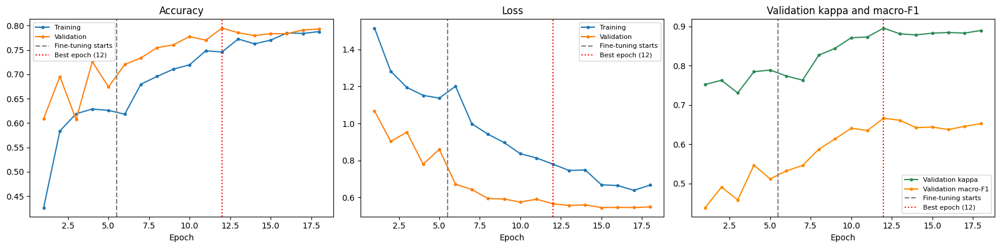

Best epoch: 12, validation kappa 0.8956
       phase  accuracy  val_accuracy   loss  val_loss  val_qwk
4       head     0.626         0.674  1.137     0.860    0.789
11  finetune     0.746         0.795  0.780     0.566    0.896
17  finetune     0.788         0.793  0.666     0.548    0.890


In [ ]:
# Cell 29 - Step 6A: accuracy and loss curves of the final model (from its saved training history)
hist = pd.read_csv(os.path.join(RESULTS_DIR, 'history_E4_top30_lr1e-4.csv'))
ep = np.arange(1, len(hist) + 1)
switch = (hist['phase'] == 'head').sum() + 0.5      # boundary between head training and fine-tuning
best = int(hist['val_qwk'].idxmax()) + 1             # epoch whose weights were restored

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, (tr, va, title) in zip(axes[:2], [('accuracy', 'val_accuracy', 'Accuracy'), ('loss', 'val_loss', 'Loss')]):
    ax.plot(ep, hist[tr], 'o-', ms=3, label='Training')
    ax.plot(ep, hist[va], 'o-', ms=3, label='Validation')
    ax.set_title(title); ax.set_xlabel('Epoch')
axes[2].plot(ep, hist['val_qwk'], 'o-', ms=3, color='seagreen', label='Validation kappa')
axes[2].plot(ep, hist['val_macro_f1'], 'o-', ms=3, color='darkorange', label='Validation macro-F1')
axes[2].set_title('Validation kappa and macro-F1'); axes[2].set_xlabel('Epoch')
for ax in axes:
    ax.axvline(switch, ls='--', color='gray', label='Fine-tuning starts')
    ax.axvline(best, ls=':', color='red', label=f'Best epoch ({best})')
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig('15_learning_curves'); plt.show()

print(f'Best epoch: {best}, validation kappa {hist.val_qwk.max():.4f}')
print(hist.iloc[[int(switch - 0.5) - 1, best - 1, len(hist) - 1]]
      [['phase', 'accuracy', 'val_accuracy', 'loss', 'val_loss', 'val_qwk']].round(3))

Validation kappa (should be ~0.8956): 0.8956

QWK                         0.8463
Accuracy                    0.7476
Macro precision             0.5788
Macro recall                0.6199
Macro F1                    0.5780
Healthy vs DR accuracy      0.9732
DR sensitivity              0.9843
DR specificity              0.9628
DR ROC-AUC                  0.9946
Referable DR sensitivity    0.7882
Referable DR specificity    0.9562

Per-class results:
               precision    recall  f1-score   support

        No DR      0.985     0.963     0.974       269
         Mild      0.419     0.706     0.526        51
     Moderate      0.725     0.475     0.574       139
       Severe      0.265     0.520     0.351        25
Proliferative      0.500     0.436     0.466        39

     accuracy                          0.748       523
    macro avg      0.579     0.620     0.578       523
 weighted avg      0.790     0.748     0.756       523



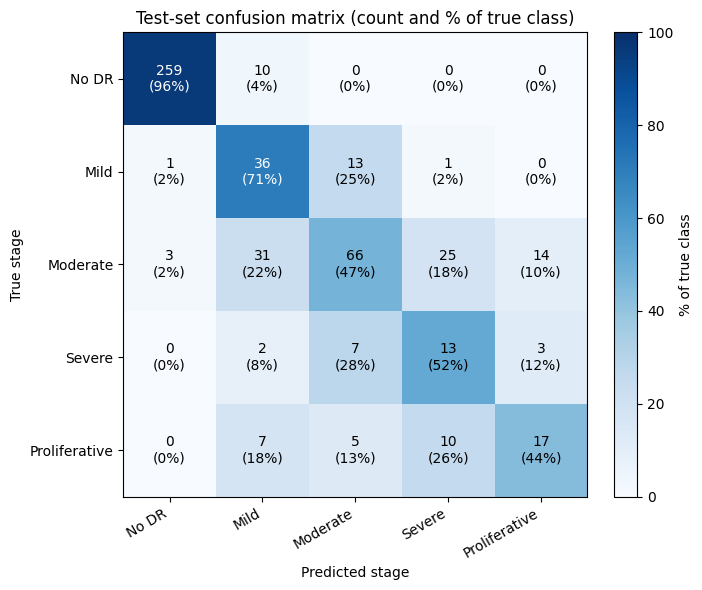

Errors: 132/523 | neighbouring-stage errors: 100 (76%) | 2+ stages off: 32 | Proliferative predicted as No DR: 0


In [ ]:
# Cell 30 - Step 6B: load the final model and evaluate it ONCE on the test set
from sklearn.metrics import (cohen_kappa_score, accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score)

# 1. Load the saved model and copy its weights into a 32-bit copy (the saved one uses 16-bit maths for the GPU)
final16 = keras.models.load_model(os.path.join(MODEL_DIR, 'final_model.keras'))
model, base = build_model('efficientnetb0')
src_base = next(l for l in final16.layers if isinstance(l, keras.Model))
for layer in base.layers:
    layer.set_weights(src_base.get_layer(layer.name).get_weights())
model.layers[-1].set_weights(final16.layers[-1].get_weights())
del final16

# 2. Safety check: validation kappa must match the training log
val_pred = model.predict(make_ds('val', 'v2'), verbose=0).argmax(1)
print(f"Validation kappa (should be ~0.8956): {cohen_kappa_score(y_all[idx['val']], val_pred, weights='quadratic'):.4f}\n")

# 3. The one and only test-set evaluation
y_test = y_all[idx['test']]
probs = model.predict(make_ds('test', 'v2'), verbose=0)
pred = probs.argmax(1)

def sens_spec(t, p):
    """Sensitivity = share of sick eyes found; specificity = share of healthy eyes correctly cleared."""
    return np.sum(t & p) / np.sum(t), np.sum(~t & ~p) / np.sum(~t)

mp, mr, mf, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
dr_sens, dr_spec = sens_spec(y_test > 0, pred > 0)
ref_sens, ref_spec = sens_spec(y_test >= 2, pred >= 2)
results = pd.Series({
    'QWK': cohen_kappa_score(y_test, pred, weights='quadratic'),
    'Accuracy': accuracy_score(y_test, pred),
    'Macro precision': mp, 'Macro recall': mr, 'Macro F1': mf,
    'Healthy vs DR accuracy': accuracy_score(y_test > 0, pred > 0),
    'DR sensitivity': dr_sens, 'DR specificity': dr_spec,
    'DR ROC-AUC': roc_auc_score(y_test > 0, 1 - probs[:, 0]),
    'Referable DR sensitivity': ref_sens, 'Referable DR specificity': ref_spec,
}).round(4)
print(results.to_string())
results.to_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'), header=['value'])
print('\nPer-class results:')
print(classification_report(y_test, pred, target_names=STAGES, digits=3, zero_division=0))

# Save every test prediction (used for Grad-CAM and error analysis)
test_df = df.iloc[idx['test']][['id_code', 'diagnosis', 'stage', 'resolution']].copy()
test_df['pred'], test_df['confidence'] = pred, probs.max(1).round(4)
test_df.to_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'), index=False)

# 4. Confusion matrix (Figure 16)
cm = confusion_matrix(y_test, pred, labels=range(5))
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm[i, j]}\n({cm_pct[i, j]:.0f}%)', ha='center', va='center', fontsize=10,
                color='white' if cm_pct[i, j] > 55 else 'black')
ax.set_xticks(range(5), STAGES, rotation=30, ha='right'); ax.set_yticks(range(5), STAGES)
ax.set_xlabel('Predicted stage'); ax.set_ylabel('True stage')
ax.set_title('Test-set confusion matrix (count and % of true class)')
plt.colorbar(im, ax=ax, fraction=0.046, label='% of true class')
plt.tight_layout(); save_fig('16_confusion_matrix'); plt.show()

errors = int(np.sum(y_test != pred)); near = int(np.sum(np.abs(y_test - pred) == 1))
print(f'Errors: {errors}/{len(y_test)} | neighbouring-stage errors: {near} ({near / errors:.0%}) | '
      f'2+ stages off: {errors - near} | Proliferative predicted as No DR: {cm[4, 0]}')

In [ ]:
# Cell 31 - Step 6C: hard test: does performance hold where the camera gives no clue?
MIXED = ['2416x1736', '2588x1958']
hard = np.isin(test_df['resolution'].values, MIXED)

def subset_metrics(mask, name):
    t, p = y_test[mask], pred[mask]
    return {'Test set': name, 'Images': int(mask.sum()),
            'QWK': cohen_kappa_score(t, p, weights='quadratic'),
            'Macro-F1': f1_score(t, p, average='macro', zero_division=0),
            'Accuracy': accuracy_score(t, p),
            'Healthy vs DR acc': accuracy_score(t > 0, p > 0)}

hard_table = pd.DataFrame([subset_metrics(np.ones(len(y_test), bool), 'Full test set'),
                           subset_metrics(hard, 'Hard: mixed cameras'),
                           subset_metrics(~hard, 'Other cameras')]).round(3)
print(hard_table.to_string(index=False))
hard_table.to_csv(os.path.join(RESULTS_DIR, 'hard_test.csv'), index=False)

           Test set  Images   QWK  Macro-F1  Accuracy  Healthy vs DR acc
      Full test set     523 0.846     0.578     0.748              0.973
Hard: mixed cameras     156 0.743     0.607     0.628              0.962
      Other cameras     367 0.869     0.517     0.798              0.978


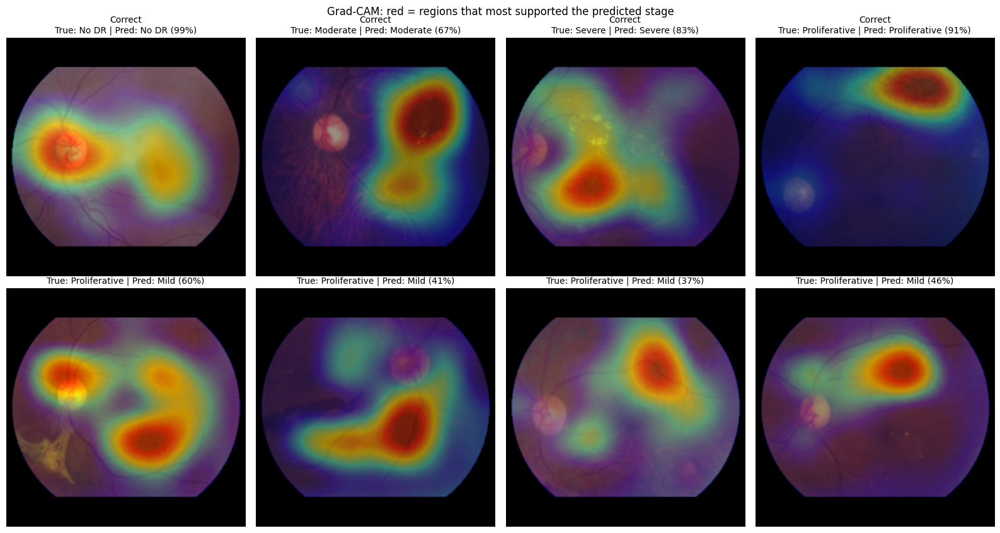

In [ ]:
# Cell 32 - Step 6D: Grad-CAM: which regions made the model decide?
inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
feat_model = keras.Model(inp, base(inp, training=False))   # last convolutional feature maps (7 x 7 x 1280)
W = model.layers[-1].get_weights()[0]                      # Dense weights: 1280 features x 5 stages

def grad_cam(k):
    """Heatmap for test image k and its predicted stage. For a pooling -> Dense head, Grad-CAM equals
    weighting each feature map by that stage's Dense weight (the gradient of the stage score)."""
    gi = idx['test'][k]
    A = feat_model.predict(arrays['v2'][gi][None].astype('float32'), verbose=0)[0]
    cam = np.maximum(A @ W[:, pred[k]], 0)                 # keep only positive evidence
    cam = cv2.resize(cam / (cam.max() + 1e-8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    heat = cv2.applyColorMap(np.uint8(255 * np.clip(cam, 0, 1)), cv2.COLORMAP_JET)[:, :, ::-1]
    img = arrays['v0'][gi]                                  # natural-looking image for display
    eye = img.max(axis=2, keepdims=True) > 0
    return ((0.6 * img + 0.4 * heat) * eye).astype(np.uint8)

# Pick examples: correct predictions (one per stage) and the biggest mistakes
rng = np.random.default_rng(42)
correct = [int(rng.choice(np.where((y_test == s) & (pred == s))[0]))
           for s in [0, 2, 3, 4] if np.any((y_test == s) & (pred == s))]
wrong_all = np.where(y_test != pred)[0]
wrong = wrong_all[np.argsort(-np.abs(y_test[wrong_all] - pred[wrong_all]))][:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8.6))
for row, (ks, label) in enumerate([(correct, 'Correct'), (wrong, 'Incorrect')]):
    for col in range(4):
        ax = axes[row, col]; ax.axis('off')
        if col < len(ks):
            k = ks[col]
            ax.imshow(grad_cam(k))
            ax.set_title(f'{label}\nTrue: {STAGES[y_test[k]]} | Pred: {STAGES[pred[k]]} '
                         f'({probs[k].max():.0%})', fontsize=10)
plt.suptitle('Grad-CAM: red = regions that most supported the predicted stage', fontsize=12)
plt.tight_layout(); save_fig('17_gradcam'); plt.show()


In [ ]:
# Is the hard-test drop caused by a different class mix, or by camera cues?
from sklearn.metrics import recall_score
rows = []
for name, mask in [('Hard: mixed cameras', hard), ('Other cameras', ~hard)]:
    r = recall_score(y_test[mask], pred[mask], labels=range(5), average=None, zero_division=0)
    n = np.bincount(y_test[mask], minlength=5)
    rows.append([name] + [f'{ri:.2f} (n={ni})' for ri, ni in zip(r, n)])
print(pd.DataFrame(rows, columns=['Subset'] + STAGES).to_string(index=False))

             Subset        No DR        Mild    Moderate      Severe Proliferative
Hard: mixed cameras  0.88 (n=32) 0.72 (n=39) 0.47 (n=53) 0.69 (n=13)   0.42 (n=19)
      Other cameras 0.97 (n=237) 0.67 (n=12) 0.48 (n=86) 0.33 (n=12)   0.45 (n=20)


In [8]:
# Cell 33a - load the final model for the app (no evaluation needed, about 1 minute on CPU)
final16 = keras.models.load_model(os.path.join(MODEL_DIR, 'final_model.keras'))
model, base = build_model('efficientnetb0')
src_base = next(l for l in final16.layers if isinstance(l, keras.Model))
for layer in base.layers:
    layer.set_weights(src_base.get_layer(layer.name).get_weights())
model.layers[-1].set_weights(final16.layers[-1].get_weights())
del final16

inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
feat_model = keras.Model(inp, base(inp, training=False))   # for Grad-CAM
W = model.layers[-1].get_weights()[0]
print('Model ready for the app.')

Model ready for the app.


In [10]:
# Cell 33 - Step 7: Gradio prototype (improved design, runs on CPU)
!pip install -q gradio
import gradio as gr, zipfile, time, inspect

# ---------- demo examples: one correct test image per stage + one mistake (cached in Drive) ----------
test_df = pd.read_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'))
DEMO_DIR = os.path.join(PROJECT_DIR, 'demo_examples'); os.makedirs(DEMO_DIR, exist_ok=True)
DRIVE_ZIP = os.path.join(PROJECT_DIR, 'raw', 'aptos2019-blindness-detection.zip')
picks = [test_df[(test_df.diagnosis == s) & (test_df.pred == s)].iloc[0]['id_code'] for s in range(5)]
picks.append(test_df[test_df.diagnosis != test_df.pred].iloc[0]['id_code'])
missing = [c for c in picks if not os.path.exists(os.path.join(DEMO_DIR, f'{c}.png'))]
if missing:                                   # only open the big zip if an example is not cached yet
    with zipfile.ZipFile(DRIVE_ZIP) as z:
        for code in missing:
            with open(os.path.join(DEMO_DIR, f'{code}.png'), 'wb') as f:
                f.write(z.read(f'train_images/{code}.png'))
examples = [[os.path.join(DEMO_DIR, f'{c}.png')] for c in picks]

# ---------- look and feel ----------
COLORS = ['#2e7d32', '#9e9d24', '#ef8f00', '#e65100', '#c62828']   # No DR -> Proliferative
CSS = """
.gradio-container {max-width: 1150px !important; margin: auto;}
#header {text-align: center; padding: 18px 10px 4px;}
#header h1 {font-size: 1.9rem; margin-bottom: 4px;}
#header p {opacity: .8; margin: 0;}
.card {border: 1px solid var(--border-color-primary); border-radius: 14px; padding: 18px 20px;
       background: var(--block-background-fill);}
.card .lbl {font-size: .8rem; text-transform: uppercase; letter-spacing: .06em; opacity: .7;}
.card .stage {font-size: 2rem; font-weight: 700; margin: 2px 0 10px;}
.card .bar {height: 10px; border-radius: 6px; background: rgba(127,127,127,.2); overflow: hidden;}
.card .bar div {height: 100%; border-radius: 6px;}
.card .conf {font-size: .9rem; margin: 6px 0 12px; opacity: .85;}
.card .pill {display: inline-block; padding: 4px 12px; border-radius: 999px; margin: 0 6px 6px 0; font-size: .9rem;}
.card .yes {background: rgba(198,40,40,.15); color: #c62828;}
.card .no {background: rgba(46,125,50,.15); color: #2e7d32;}
.card .warn {margin-top: 10px; padding: 8px 12px; border-radius: 10px; background: rgba(239,143,0,.18); color: #b26a00;}
.card .time {margin-top: 10px; font-size: .8rem; opacity: .6;}
#footer {text-align: center; font-size: .85rem; opacity: .7; padding: 8px;}
"""
theme = gr.themes.Soft(primary_hue='blue', neutral_hue='slate')

EMPTY_CARD = ("<div class='card'><div class='lbl'>Result</div>"
              "<div style='opacity:.7;margin-top:6px'>Upload a fundus photograph or click an example to start.</div></div>")

ABOUT_MD = """
**Model:** EfficientNetB0 pretrained on ImageNet, fine-tuned on APTOS 2019 (2,436 training images, 5 ICDR stages).
**Preprocessing:** retina crop, common field-of-view mask, bilateral denoising and Ben Graham colour normalisation, the same as training.

| Test results (523 unseen images) | |
|---|---|
| Quadratic weighted kappa | 0.846 |
| 5-stage accuracy | 74.8% |
| Healthy vs DR accuracy | 97.3% |
| DR sensitivity / specificity | 98.4% / 96.3% |
| ROC-AUC (healthy vs DR) | 0.995 |
"""

def result_card(probs, cls, secs):
    """Colour-coded HTML summary of the prediction."""
    conf, p_dr, p_ref = probs[cls], 1 - probs[0], probs[2:].sum()
    warn = ("<div class='warn'>\u26a0\ufe0f Low confidence: recommend review by a specialist</div>"
            if conf < 0.6 else "")
    return f"""
<div class='card'>
  <div class='lbl'>Predicted stage</div>
  <div class='stage' style='color:{COLORS[cls]}'>{STAGES[cls]}</div>
  <div class='bar'><div style='width:{conf * 100:.0f}%;background:{COLORS[cls]}'></div></div>
  <div class='conf'>{conf:.0%} confidence</div>
  <span class='pill {"yes" if cls > 0 else "no"}'>DR present: {"Yes" if cls > 0 else "No"} ({p_dr:.0%})</span>
  <span class='pill {"yes" if cls >= 2 else "no"}'>Referable: {"Yes" if cls >= 2 else "No"} ({p_ref:.0%})</span>
  {warn}
  <div class='time'>Processed in {secs:.1f} s</div>
</div>"""

def cam_overlay(x_v2, display, cls):
    """Grad-CAM heatmap (same method as Cell 32) over the natural-colour image."""
    A = feat_model.predict(x_v2[None].astype('float32'), verbose=0)[0]
    cam = np.maximum(A @ W[:, cls], 0)
    cam = cv2.resize(cam / (cam.max() + 1e-8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    heat = cv2.applyColorMap(np.uint8(255 * np.clip(cam, 0, 1)), cv2.COLORMAP_JET)[:, :, ::-1]
    eye = display.max(axis=2, keepdims=True) > 0
    return ((0.6 * display + 0.4 * heat) * eye).astype(np.uint8)

def analyse(image):
    """Full pipeline for one photo: same preprocessing as training -> prediction -> Grad-CAM."""
    if image is None:
        return EMPTY_CARD, None, None, None
    t0 = time.time()
    g, m = geometry(np.asarray(image.convert('RGB')))
    display = finish(g)                              # natural colours, for the heatmap
    x = finish(photometric(g, m, 'v2'))              # exactly the training preprocessing (v2)
    probs = model.predict(x[None].astype('float32'), verbose=0)[0]
    cls = int(probs.argmax())
    cam = cam_overlay(x, display, cls)
    return result_card(probs, cls, time.time() - t0), {s: float(p) for s, p in zip(STAGES, probs)}, x, cam

# ---------- layout ----------
style = dict(theme=theme, css=CSS)
style_in_blocks = 'css' in inspect.signature(gr.Blocks.__init__).parameters   # differs between Gradio versions

with gr.Blocks(title='DR Stage Detection', **(style if style_in_blocks else {})) as demo:
    gr.HTML("<div id='header'><h1>Diabetic Retinopathy Stage Detection</h1>"
            "<p>Upload a retinal fundus photograph to estimate its ICDR stage, with a Grad-CAM explanation.</p></div>")
    with gr.Row(equal_height=False):
        with gr.Column(scale=5):
            img_in = gr.Image(type='pil', label='Fundus photograph', height=330)
            btn = gr.Button('Analyse image', variant='primary', size='lg')
            gr.Examples(examples=examples, inputs=img_in, label='Example test images (click one)')
        with gr.Column(scale=7):
            card = gr.HTML(EMPTY_CARD)
            probs_out = gr.Label(num_top_classes=5, label='Stage probabilities')
            with gr.Row():
                pre_out = gr.Image(label='Preprocessed input (what the model sees)', height=260)
                cam_out = gr.Image(label='Grad-CAM: regions behind the prediction', height=260)
    with gr.Accordion('About the model', open=False):
        gr.Markdown(ABOUT_MD)
    gr.HTML("<div id='footer'>Computer Vision coursework prototype</div>")

    outputs = [card, probs_out, pre_out, cam_out]
    img_in.change(analyse, inputs=img_in, outputs=outputs)   # runs on upload or example click
    btn.click(analyse, inputs=img_in, outputs=outputs)

demo.launch(share=True, **({} if style_in_blocks else style))

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7deb9e8aa550fd6237.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
